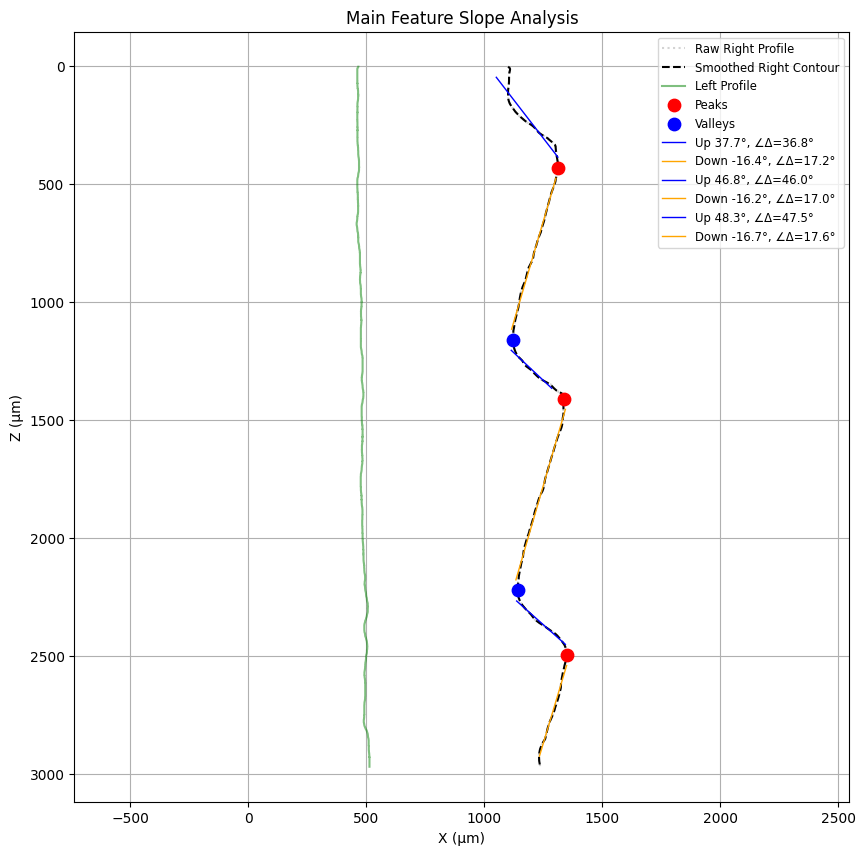


=== 主要趨勢線角度分析 ===
趨勢線: Up, 角度: 37.65°, 與基底夾角差: 36.79°
趨勢線: Down, 角度: -16.36°, 與基底夾角差: 17.22°
趨勢線: Up, 角度: 46.84°, 與基底夾角差: 45.98°
趨勢線: Down, 角度: -16.18°, 與基底夾角差: 17.04°
趨勢線: Up, 角度: 48.33°, 與基底夾角差: 47.47°
趨勢線: Down, 角度: -16.69°, 與基底夾角差: 17.55°


In [82]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from math import atan2, degrees
from sklearn.linear_model import LinearRegression


def analyze_feature_slopes(
    image_path,
    px_size=1.12,
    z_scale=1.12,
    peak_prominence=50.0,
    peak_distance=200,
    fit_margin=40,
    min_r2=0.90,
):
    """
    分析影像右側輪廓，找出連接主要波峰和波谷的趨勢線。

    Args:
        image_path (str): 影像檔案路徑。
        px_size (float): X方向每像素代表的物理尺寸 (μm)。
        z_scale (float): Z方向每像素代表的物理尺寸 (μm)。
        peak_prominence (float): 波峰/波谷的顯著性(μm)。值越大，只會偵測越主要的特徵。
        peak_distance (int): 波峰/波谷之間的最小垂直距離(像素)。值越大，特徵點越少。
        fit_margin (int): 擬合時在特徵點兩端留下的邊界(像素)，以避開曲線部分。
        min_r2 (float): 擬合直線的最小 R-squared 值，用於過濾掉非線性區段。
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"錯誤：無法讀取影像路徑 {image_path}")
        return

    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
    H, W = binary.shape

    # 提取輪廓
    profile_left_px, profile_right_px, valid_z_indices = [], [], []
    for y in range(H):
        cols = np.where(binary[y] == 255)[0]
        if len(cols) > 0:
            profile_left_px.append(cols[0])
            profile_right_px.append(cols[-1])
            valid_z_indices.append(y)

    if not valid_z_indices:
        print("在影像中未偵測到輪廓。")
        return

    # 轉換為物理尺寸
    z_vals = np.array(valid_z_indices) * z_scale
    x_vals_left = np.array(profile_left_px) * px_size
    x_vals_right_raw = np.array(profile_right_px) * px_size

    # 平滑右輪廓
    x_vals_right_smoothed = savgol_filter(
        x_vals_right_raw, window_length=51, polyorder=3
    )

    # 計算基準線角度
    reg_base = LinearRegression().fit(z_vals.reshape(-1, 1), x_vals_left.reshape(-1, 1))
    slope_base = reg_base.coef_[0][0]
    angle_base = degrees(atan2(slope_base, 1))

    # --- 步驟 1: 偵測主要波峰與波谷 ---
    # 將 prominence 參數從物理單位轉為像素單位
    prominence_px = peak_prominence / px_size

    # 找波峰 (x 座標的極大值)
    peaks, _ = find_peaks(
        x_vals_right_smoothed, prominence=prominence_px, distance=peak_distance
    )
    # 找波谷 (x 座標的極小值，相當於找 -x 的極大值)
    valleys, _ = find_peaks(
        -x_vals_right_smoothed, prominence=prominence_px, distance=peak_distance
    )

    # --- 步驟 2: 組合並排序所有特徵點 (包含起點和終點) ---
    feature_points = [(p, "Peak") for p in peaks] + [(v, "Valley") for v in valleys]
    feature_points.append((0, "Start"))
    feature_points.append((len(z_vals) - 1, "End"))
    feature_points.sort(key=lambda x: x[0])

    # 移除重複的索引
    unique_features = []
    if feature_points:
        unique_features.append(feature_points[0])
        for i in range(1, len(feature_points)):
            if feature_points[i][0] != feature_points[i - 1][0]:
                unique_features.append(feature_points[i])

    # --- 步驟 3: 在相鄰特徵點之間擬合直線 ---
    fitted_angles = []
    for i in range(len(unique_features) - 1):
        idx1, _ = unique_features[i]
        idx2, _ = unique_features[i + 1]

        # 應用邊界，避免在峰/谷的頂端進行擬合
        fit_idx1 = idx1 + fit_margin
        fit_idx2 = idx2 - fit_margin

        # 如果區段太短則跳過
        if fit_idx2 <= fit_idx1 or (fit_idx2 - fit_idx1) < 20:
            continue

        z_seg = z_vals[fit_idx1 : fit_idx2 + 1]
        x_seg = x_vals_right_smoothed[fit_idx1 : fit_idx2 + 1]

        # 進行線性擬合
        reg = LinearRegression().fit(z_seg.reshape(-1, 1), x_seg.reshape(-1, 1))

        # 使用 R-squared 過濾掉非線性區段
        r2 = reg.score(z_seg.reshape(-1, 1), x_seg.reshape(-1, 1))
        if r2 < min_r2:
            continue

        slope = reg.coef_[0][0]
        angle = degrees(atan2(slope, 1))
        delta = abs(angle - angle_base)
        label = "Up" if slope > 0 else "Down"

        fitted_angles.append((fit_idx1, fit_idx2, angle, label, delta))

    # --- 步驟 4: 繪圖與輸出 ---
    plt.figure(figsize=(10, 10))
    plt.plot(
        x_vals_right_raw,
        z_vals,
        label="Raw Right Profile",
        color="lightgray",
        linestyle=":",
    )
    plt.plot(
        x_vals_right_smoothed,
        z_vals,
        label="Smoothed Right Contour",
        color="black",
        linestyle="--",
        linewidth=1.5,
    )
    plt.plot(x_vals_left, z_vals, label="Left Profile", color="green", alpha=0.5)

    # 繪製偵測到的主要特徵點
    plt.scatter(
        x_vals_right_smoothed[peaks],
        z_vals[peaks],
        color="red",
        s=80,
        zorder=5,
        label="Peaks",
    )
    plt.scatter(
        x_vals_right_smoothed[valleys],
        z_vals[valleys],
        color="blue",
        s=80,
        zorder=5,
        label="Valleys",
    )

    # 繪製擬合的趨勢線
    for idx1, idx2, angle, label, delta in fitted_angles:
        z_fit = z_vals[idx1 : idx2 + 1]
        model = LinearRegression().fit(
            z_fit.reshape(-1, 1), x_vals_right_smoothed[idx1 : idx2 + 1].reshape(-1, 1)
        )

        # 為了讓線條延伸到整個區段，我們用區段的端點來預測
        z_endpoints = z_vals[[idx1, idx2]]
        x_pred = model.predict(z_endpoints.reshape(-1, 1))

        line_color = "blue" if label == "Up" else "orange"
        plt.plot(
            x_pred,
            z_endpoints,
            linewidth=1,
            color=line_color,
            label=f"{label} {angle:.1f}°, ∠Δ={delta:.1f}°",
        )

    plt.xlabel("X (μm)")
    plt.ylabel("Z (μm)")
    plt.title("Main Feature Slope Analysis")
    plt.legend(fontsize="small")
    plt.grid(True)
    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.show()

    print("\n=== 主要趨勢線角度分析 ===")
    fitted_angles.sort(key=lambda x: x[0])
    for _, _, angle, label, delta in fitted_angles:
        print(f"趨勢線: {label}, 角度: {angle:.2f}°, 與基底夾角差: {delta:.2f}°")


# --- 執行分析 ---
# 【請在此調整參數以達到最佳效果】
analyze_feature_slopes(
    image_path=r"\\140.114.141.95\nas\112\112033635_CHI\GA\0806OM\0.9_0.3_60_01_RB.png",  # <--- 請務必改成你自己的圖片路徑
    px_size=0.56,
    z_scale=0.56,
    # px_size=1.12,
    # z_scale=1.12,
    peak_prominence=10.0,  # 波峰/谷的顯著程度，值越大，特徵點越少
    peak_distance=10,  # 特徵點之間的最小距離，避免抓到鄰近的雜訊
    fit_margin=80,  # 在峰谷兩端留多少邊界不參與計算
    min_r2=0.80,  # 擬合優度(R-squared)的門檻，越高代表越要求區段為直線
)

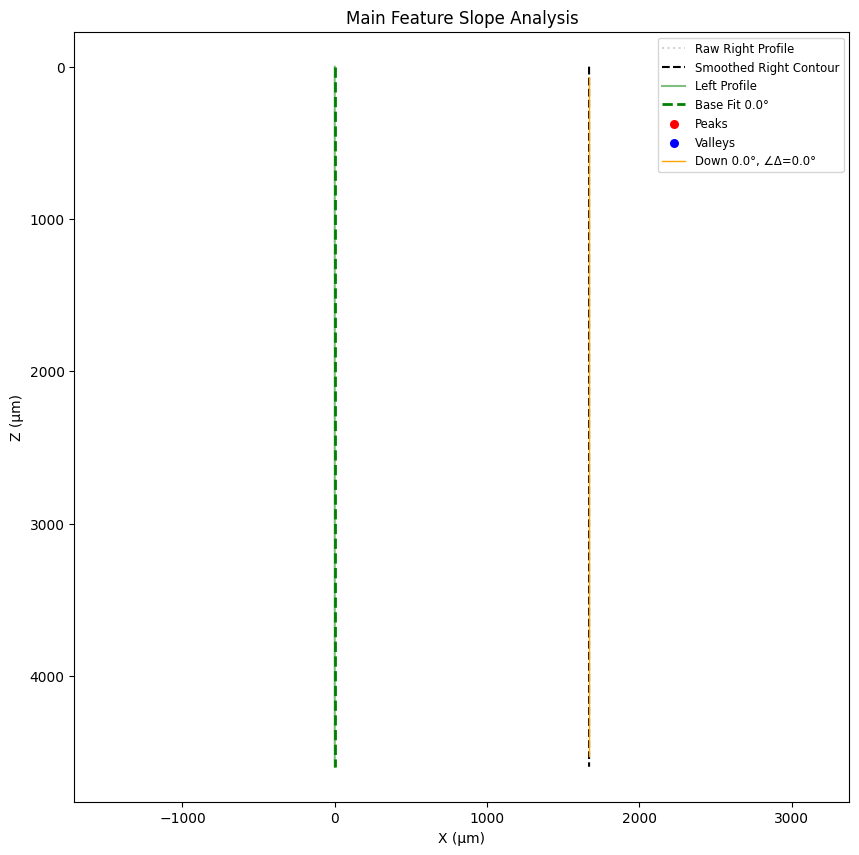


=== 主要趨勢線角度分析 ===
趨勢線: Down, 角度: 0.00°, 與基底夾角差: 0.00°


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from math import atan2, degrees
from sklearn.linear_model import LinearRegression


def analyze_feature_slopes(
    image_path,
    px_size=1.12,
    z_scale=1.12,
    peak_prominence=50.0,
    peak_distance=200,
    fit_margin=40,
    min_r2=0.90,
):
    """
    分析影像右側輪廓，找出連接主要波峰和波谷的趨勢線。

    Args:
        image_path (str): 影像檔案路徑。
        px_size (float): X方向每像素代表的物理尺寸 (μm)。
        z_scale (float): Z方向每像素代表的物理尺寸 (μm)。
        peak_prominence (float): 波峰/波谷的顯著性(μm)。值越大，只會偵測越主要的特徵。
        peak_distance (int): 波峰/波谷之間的最小垂直距離(像素)。值越大，特徵點越少。
        fit_margin (int): 擬合時在特徵點兩端留下的邊界(像素)，以避開曲線部分。
        min_r2 (float): 擬合直線的最小 R-squared 值，用於過濾掉非線性區段。
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"錯誤：無法讀取影像路徑 {image_path}")
        return

    _, binary =  cv2.threshold(img, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU, 255, cv2.THRESH_BINARY)
    H, W = binary.shape

    # 提取輪廓
    profile_left_px, profile_right_px, valid_z_indices = [], [], []
    for y in range(H):
        cols = np.where(binary[y] == 255)[0]
        if len(cols) > 0:
            profile_left_px.append(cols[0])
            profile_right_px.append(cols[-1])
            valid_z_indices.append(y)

    if not valid_z_indices:
        print("在影像中未偵測到輪廓。")
        return

    # 轉換為物理尺寸
    z_vals = np.array(valid_z_indices) * z_scale
    x_vals_left = np.array(profile_left_px) * px_size
    x_vals_right_raw = np.array(profile_right_px) * px_size

    # 平滑右輪廓
    x_vals_right_smoothed = savgol_filter(
        x_vals_right_raw, window_length=71, polyorder=3
    )

    # 計算基準線角度
    reg_base = LinearRegression().fit(z_vals.reshape(-1, 1), x_vals_left.reshape(-1, 1))
    slope_base = reg_base.coef_[0][0]
    angle_base = degrees(atan2(slope_base, 1))

    # --- 步驟 1: 偵測主要波峰與波谷 ---
    prominence_px = peak_prominence / px_size
    peaks, _ = find_peaks(
        x_vals_right_smoothed, prominence=prominence_px, distance=peak_distance
    )
    valleys, _ = find_peaks(
        -x_vals_right_smoothed, prominence=prominence_px, distance=peak_distance
    )

    # --- 步驟 2: 組合並排序所有特徵點 ---
    feature_points = [(p, "Peak") for p in peaks] + [(v, "Valley") for v in valleys]
    feature_points.append((0, "Start"))
    feature_points.append((len(z_vals) - 1, "End"))
    feature_points.sort(key=lambda x: x[0])

    unique_features = []
    if feature_points:
        unique_features.append(feature_points[0])
        for i in range(1, len(feature_points)):
            if feature_points[i][0] != feature_points[i - 1][0]:
                unique_features.append(feature_points[i])

    # --- 步驟 3: 在相鄰特徵點之間擬合直線 ---
    fitted_angles = []
    for i in range(len(unique_features) - 1):
        idx1, _ = unique_features[i]
        idx2, _ = unique_features[i + 1]
        fit_idx1, fit_idx2 = idx1 + fit_margin, idx2 - fit_margin

        if fit_idx2 <= fit_idx1 or (fit_idx2 - fit_idx1) < 20:
            continue

        z_seg = z_vals[fit_idx1 : fit_idx2 + 1]
        x_seg = x_vals_right_smoothed[fit_idx1 : fit_idx2 + 1]

        reg = LinearRegression().fit(z_seg.reshape(-1, 1), x_seg.reshape(-1, 1))
        r2 = reg.score(z_seg.reshape(-1, 1), x_seg.reshape(-1, 1))
        if r2 < min_r2:
            continue

        slope = reg.coef_[0][0]
        angle = degrees(atan2(slope, 1))
        delta = abs(angle - angle_base)
        label = "Up" if slope > 0 else "Down"
        fitted_angles.append((fit_idx1, fit_idx2, angle, label, delta))

    # --- 步驟 4: 繪圖與輸出 ---
    plt.figure(figsize=(10, 10))
    plt.plot(
        x_vals_right_raw,
        z_vals,
        label="Raw Right Profile",
        color="lightgray",
        linestyle=":",
    )
    plt.plot(
        x_vals_right_smoothed,
        z_vals,
        label="Smoothed Right Contour",
        color="black",
        linestyle="--",
        linewidth=1.5,
    )
    plt.plot(x_vals_left, z_vals, label="Left Profile", color="green", alpha=0.5)

    # ++++++++++++++++ 新增的程式碼 ++++++++++++++++
    # 準備繪製基準線的數據
    z_fit_base = np.linspace(z_vals.min(), z_vals.max(), 100)
    x_fit_base = reg_base.predict(z_fit_base.reshape(-1, 1))
    # 繪製基準線
    plt.plot(
        x_fit_base, z_fit_base, "g--", linewidth=2, label=f"Base Fit {angle_base:.1f}°"
    )
    # +++++++++++++++++++++++++++++++++++++++++++++++

    # 繪製偵測到的主要特徵點
    plt.scatter(
        x_vals_right_smoothed[peaks],
        z_vals[peaks],
        color="red",
        s=30,
        zorder=5,
        label="Peaks",
    )
    plt.scatter(
        x_vals_right_smoothed[valleys],
        z_vals[valleys],
        color="blue",
        s=30,
        zorder=5,
        label="Valleys",
    )

    # 繪製擬合的趨勢線
    for idx1, idx2, angle, label, delta in fitted_angles:
        z_fit = z_vals[idx1 : idx2 + 1]
        model = LinearRegression().fit(
            z_fit.reshape(-1, 1), x_vals_right_smoothed[idx1 : idx2 + 1].reshape(-1, 1)
        )
        z_endpoints = z_vals[[idx1, idx2]]
        x_pred = model.predict(z_endpoints.reshape(-1, 1))
        line_color = "blue" if label == "Up" else "orange"
        plt.plot(
            x_pred,
            z_endpoints,
            linewidth=1,
            color=line_color,
            label=f"{label} {angle:.1f}°, ∠Δ={delta:.1f}°",
        )

    plt.xlabel("X (μm)")
    plt.ylabel("Z (μm)")
    plt.title("Main Feature Slope Analysis")
    plt.legend(fontsize="small")
    plt.grid(False)
    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.show()

    print("\n=== 主要趨勢線角度分析 ===")
    fitted_angles.sort(key=lambda x: x[0])
    for _, _, angle, label, delta in fitted_angles:
        print(f"趨勢線: {label}, 角度: {angle:.2f}°, 與基底夾角差: {delta:.2f}°")


# --- 執行分析 ---
# 您可以繼續使用您調整好的參數
analyze_feature_slopes(
    image_path=r"\\140.114.141.95\nas\112\112033635_CHI\GA\0806OM\0.9_0.3_60_06_RB(1024).png",
    # r"\\140.114.141.95\nas\112\112033635_CHI\GA\0726OM\0.9_0.9\0.9_0.9_60_clean.png",
    # r"C:\Users\cchih\Desktop\NTHU\MasterThesis\research_log\202507\0725\0.3_0.3_60_01.png",
    # r"C:\Users\cchih\Desktop\NTHU\MasterThesis\research_log\202507\0725\0.9_0.9_30_1.png",
    # r"\\140.114.141.95\nas\112\112033635_CHI\GA\0726OM\0.9_0.9\0.9_0.9_30_clean.png",
    # px_size=0.56,
    # z_scale=0.56,
    px_size=1.12,
    z_scale=1.12,
    peak_prominence=5.0,  # 40
    peak_distance=80,  # 150
    fit_margin=60,  # 40 #30 #20
    min_r2=0.95,  # 0.9 # 0.85
)


=== 合併後主要趨勢線角度分析 ===
趨勢線: Down, 角度: 1.66°, 與基底夾角差: 0.42°


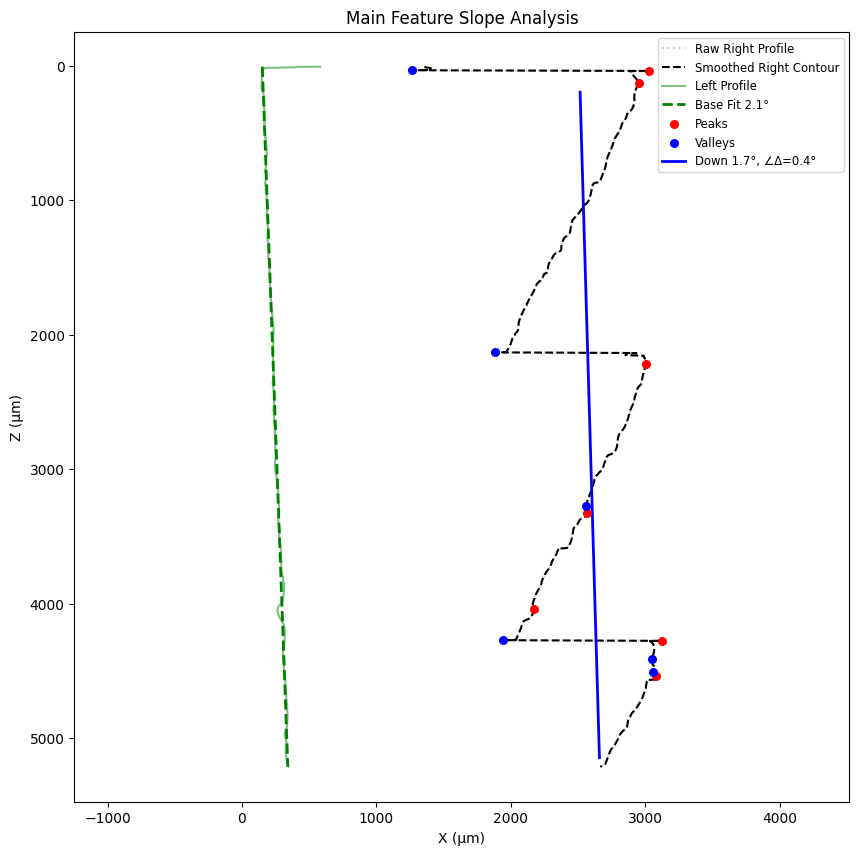

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from math import atan2, degrees
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RANSACRegressor

def analyze_feature_slopes(
    image_path,
    px_size=1.12,
    z_scale=1.12,
    peak_prominence=50.0,
    peak_distance=200,
    fit_margin=40,
    min_r2=0.90,
):
    """
    分析影像右側輪廓，找出連接主要波峰和波谷的趨勢線。

    Args:
        image_path (str): 影像檔案路徑。
        px_size (float): X方向每像素代表的物理尺寸 (μm)。
        z_scale (float): Z方向每像素代表的物理尺寸 (μm)。
        peak_prominence (float): 波峰/波谷的顯著性(μm)。值越大，只會偵測越主要的特徵。
        peak_distance (int): 波峰/波谷之間的最小垂直距離(像素)。值越大，特徵點越少。
        fit_margin (int): 擬合時在特徵點兩端留下的邊界(像素)，以避開曲線部分。
        min_r2 (float): 擬合直線的最小 R-squared 值，用於過濾掉非線性區段。
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"錯誤：無法讀取影像路徑 {image_path}")
        return

    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
    H, W = binary.shape

    # 提取輪廓
    profile_left_px, profile_right_px, valid_z_indices = [], [], []
    for y in range(H):
        cols = np.where(binary[y] == 255)[0]
        if len(cols) > 0:
            profile_left_px.append(cols[0])
            profile_right_px.append(cols[-1])
            valid_z_indices.append(y)

    if not valid_z_indices:
        print("在影像中未偵測到輪廓。")
        return

    # 轉換為物理尺寸
    z_vals = np.array(valid_z_indices) * z_scale
    x_vals_left = np.array(profile_left_px) * px_size
    x_vals_right_raw = np.array(profile_right_px) * px_size

    # 平滑右輪廓
    x_vals_right_smoothed = savgol_filter(
        x_vals_right_raw, window_length=7, polyorder=3
    )

    # 計算基準線角度
    reg_base = LinearRegression().fit(z_vals.reshape(-1, 1), x_vals_left.reshape(-1, 1))
    slope_base = reg_base.coef_[0][0]
    angle_base = degrees(atan2(slope_base, 1))

    # --- 步驟 1: 偵測主要波峰與波谷 ---
    prominence_px = peak_prominence / px_size
    peaks, _ = find_peaks(
        x_vals_right_smoothed, prominence=prominence_px, distance=peak_distance
    )
    valleys, _ = find_peaks(
        -x_vals_right_smoothed, prominence=prominence_px, distance=peak_distance
    )

    # --- 步驟 2: 組合並排序所有特徵點 ---
    feature_points = [(p, "Peak") for p in peaks] + [(v, "Valley") for v in valleys]
    feature_points.append((0, "Start"))
    feature_points.append((len(z_vals) - 1, "End"))
    feature_points.sort(key=lambda x: x[0])

    unique_features = []
    if feature_points:
        unique_features.append(feature_points[0])
        for i in range(1, len(feature_points)):
            if feature_points[i][0] != feature_points[i - 1][0]:
                unique_features.append(feature_points[i])

        # --- 步驟 3: 擬合每段特徵點之間的線性區間 ---
    raw_segments = []
    for i in range(len(unique_features) - 1):
        idx1, _ = unique_features[i]
        idx2, _ = unique_features[i + 1]
        fit_idx1, fit_idx2 = idx1 + fit_margin, idx2 - fit_margin

        if fit_idx2 <= fit_idx1 or (fit_idx2 - fit_idx1) < 20:
            continue

        z_seg = z_vals[fit_idx1 : fit_idx2 + 1]
        x_seg = x_vals_right_smoothed[fit_idx1 : fit_idx2 + 1]

        # reg = LinearRegression().fit(z_seg.reshape(-1, 1), x_seg.reshape(-1, 1))
        # r2 = reg.score(z_seg.reshape(-1, 1), x_seg.reshape(-1, 1))

        reg = RANSACRegressor().fit(z_seg.reshape(-1, 1), x_seg.reshape(-1, 1))
        inlier_mask = reg.inlier_mask_
        r2 = reg.score(
            z_seg[inlier_mask].reshape(-1, 1), x_seg[inlier_mask].reshape(-1, 1)
        )

        if r2 < min_r2:
            continue

        # slope = reg.coef_[0][0]
        slope = reg.estimator_.coef_[0][0]

        angle = degrees(atan2(slope, 1))
        label = "Up" if slope > 0 else "Down"
        delta = abs(angle - angle_base)

        raw_segments.append((fit_idx1, fit_idx2, angle, label, delta))

        # --- 步驟 4: 合併角度與方向一致的 segment，並重新擬合整段 ---
    merged_segments = []
    angle_threshold = 8.0  # 合併的最大角度差 (°)

    if raw_segments:
        current = list(raw_segments[0])
        for next_seg in raw_segments[1:]:
            if (
                next_seg[3] == current[3]  # same label (Up/Down)
                and abs(next_seg[2] - current[2]) < angle_threshold
            ):
                # Extend segment
                current[1] = next_seg[1]
            else:
                merged_segments.append(tuple(current))
                current = list(next_seg)
        merged_segments.append(tuple(current))

    # === 📈 繪圖區 ===
    plt.figure(figsize=(10, 10))
    plt.plot(
        x_vals_right_raw,
        z_vals,
        label="Raw Right Profile",
        color="lightgray",
        linestyle=":",
    )
    plt.plot(
        x_vals_right_smoothed,
        z_vals,
        label="Smoothed Right Contour",
        color="black",
        linestyle="--",
        linewidth=1.5,
    )
    plt.plot(x_vals_left, z_vals, label="Left Profile", color="green", alpha=0.5)

    # 繪製基準線
    z_fit_base = np.linspace(z_vals.min(), z_vals.max(), 100)
    x_fit_base = reg_base.predict(z_fit_base.reshape(-1, 1))
    plt.plot(
        x_fit_base, z_fit_base, "g--", linewidth=2, label=f"Base Fit {angle_base:.1f}°"
    )

    # 特徵點
    plt.scatter(
        x_vals_right_smoothed[peaks],
        z_vals[peaks],
        color="red",
        s=30,
        zorder=5,
        label="Peaks",
    )
    plt.scatter(
        x_vals_right_smoothed[valleys],
        z_vals[valleys],
        color="blue",
        s=30,
        zorder=5,
        label="Valleys",
    )

    # 🔄 重新擬合合併後的趨勢線
    print("\n=== 合併後主要趨勢線角度分析 ===")
    for idx1, idx2, _, label, _ in merged_segments:
        z_fit = z_vals[idx1 : idx2 + 1]
        x_fit = x_vals_right_raw[idx1 : idx2 + 1]

        # model = LinearRegression().fit(z_fit.reshape(-1, 1), x_fit.reshape(-1, 1))
        # slope = model.coef_[0][0]
        model = RANSACRegressor(
            estimator=LinearRegression(),
            residual_threshold=1.5,  # μm內誤差都算內點
            min_samples=0.5,
            max_trials=100,
        ).fit(z_fit.reshape(-1, 1), x_fit.reshape(-1, 1))
        # inlier_mask = reg.inlier_mask_
        # r2 = reg.score(
        #     z_seg[inlier_mask].reshape(-1, 1), x_seg[inlier_mask].reshape(-1, 1)
        # )

        # if r2 < min_r2:
        #     continue

        # slope = reg.coef_[0][0]
        slope = model.estimator_.coef_[0][0]
        angle = degrees(atan2(slope, 1))
        delta = abs(angle - angle_base)

        z_endpoints = z_vals[[idx1, idx2]]
        x_endpoints = model.predict(z_endpoints.reshape(-1, 1))

        line_color = "blue" if slope > 0 else "orange"
        plt.plot(
            x_endpoints,
            z_endpoints,
            linewidth=2,
            color=line_color,
            label=f"{label} {angle:.1f}°, ∠Δ={delta:.1f}°",
        )

        print(f"趨勢線: {label}, 角度: {angle:.2f}°, 與基底夾角差: {delta:.2f}°")

    # 繪圖設定
    plt.xlabel("X (μm)")
    plt.ylabel("Z (μm)")
    plt.title("Main Feature Slope Analysis")
    plt.legend(fontsize="small")
    plt.grid(False)
    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.show()

# --- 執行分析 ---
# 您可以繼續使用您調整好的參數
analyze_feature_slopes(
    image_path= r"\\140.114.141.95\nas\112\112033635_CHI\GA\0728OM\0.9_0.9\0.9_0.9_120.png",
    #r"\\140.114.141.95\nas\112\112033635_CHI\GA\0806OM\0.9_0.3_60_06_RB(1024).png",
    # r"\\140.114.141.95\nas\112\112033635_CHI\GA\0726OM\0.9_0.9\0.9_0.9_60_clean.png",
    # r"C:\Users\cchih\Desktop\NTHU\MasterThesis\research_log\202507\0725\0.3_0.3_60_01.png",
    # r"C:\Users\cchih\Desktop\NTHU\MasterThesis\research_log\202507\0725\0.9_0.9_30_1.png",
    # r"\\140.114.141.95\nas\112\112033635_CHI\GA\0726OM\0.9_0.9\0.9_0.9_30_clean.png",
    # px_size=0.56,
    # z_scale=0.56,
    px_size=1.12,
    z_scale=1.12,
    peak_prominence=5.0,  # 40
    peak_distance=80,  # 150
    fit_margin=60,  # 40 #30 #20
    min_r2=0.95,  # 0.9 # 0.85
)

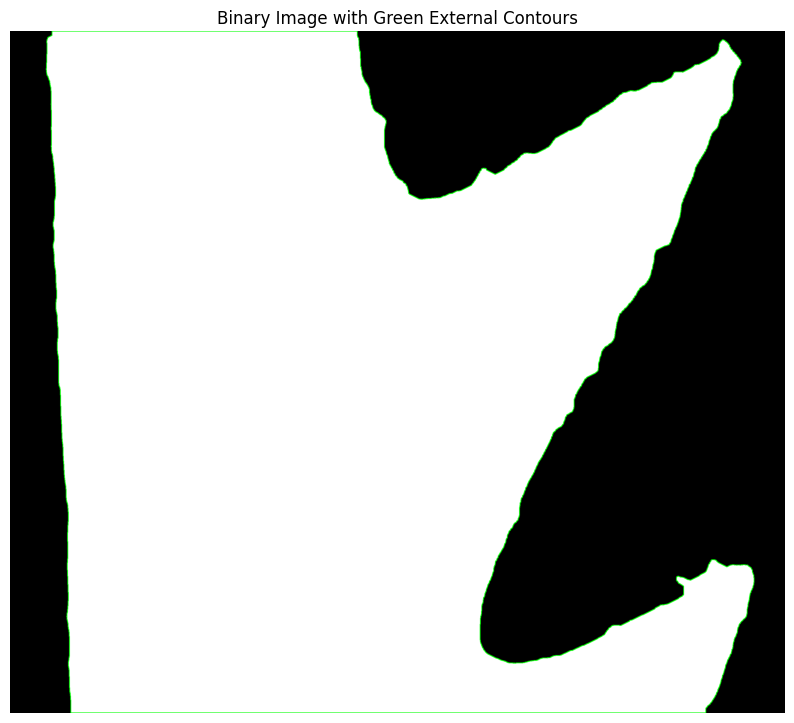

❌ 找不到稜鏡輪廓


In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from math import atan2, degrees
from sklearn.linear_model import LinearRegression


def analyze_feature_slopes(
    image_path,
    px_size=1.12,
    z_scale=1.12,
    peak_prominence=50.0,
    peak_distance=200,
    fit_margin=40,
    min_r2=0.90,
):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"❌ 無法讀取影像路徑：{image_path}")
        return

    # 二值化
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
    H, W = binary.shape
    # 去掉內部雜訊
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    binary_clean = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=15)

    # 只找最外層輪廓
    contours, _ = cv2.findContours(binary_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

    # 視覺化
    contour_vis = cv2.cvtColor(binary_clean, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(contour_vis, contours, -1, (0, 255, 0), thickness=2)

    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(contour_vis, cv2.COLOR_BGR2RGB))
    plt.title("Binary Image with Green External Contours")
    plt.axis("off")
    plt.show()

    # 找最左輪廓 = 基板
    contour_min_x = [min(c[:, 0, 0]) for c in contours]
    idx_base = np.argmin(contour_min_x)

    # === 建立基板 mask（分離稜鏡部分） ===
    mask_base = np.zeros_like(binary)
    cv2.drawContours(mask_base, [contours[idx_base]], -1, 255, thickness=cv2.FILLED)

    # 只保留左側基板（避免右側稜鏡干擾）
    x_min, y_min, w, h = cv2.boundingRect(contours[idx_base])
    x_split = x_min + int(w * 0.4)  # 只保留左 40%
    mask_base[:, x_split:] = 0

    # 閉運算連接邊緣
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    mask_base = cv2.morphologyEx(mask_base, cv2.MORPH_CLOSE, kernel)

    # 補洞
    flood = mask_base.copy()
    h_img, w_img = mask_base.shape
    mask_ff = np.zeros((h_img + 2, w_img + 2), np.uint8)
    cv2.floodFill(flood, mask_ff, (0, 0), 255)
    holes = cv2.bitwise_not(flood)
    mask_base = cv2.bitwise_or(mask_base, holes)

    # === 基板右側 profile ===
    base_right_px, base_valid_z = [], []
    for y in range(H):
        cols = np.where(mask_base[y] == 255)[0]
        if len(cols) > 0:
            base_right_px.append(cols[-1])  # 基板右側
            base_valid_z.append(y)

    z_vals_base = np.array(base_valid_z) * z_scale
    x_vals_base_right = np.array(base_right_px) * px_size

    # 基板擬合
    reg_base = LinearRegression().fit(
        z_vals_base.reshape(-1, 1), x_vals_base_right.reshape(-1, 1)
    )
    slope_base = reg_base.coef_[0][0]
    angle_base = degrees(atan2(slope_base, 1))

    # === 稜鏡 mask（排除基板輪廓） ===
    mask_prism = np.zeros_like(binary)
    for i, cnt in enumerate(contours):
        if i != idx_base:
            cv2.drawContours(mask_prism, [cnt], -1, 255, thickness=cv2.FILLED)

    # 稜鏡右側 profile
    profile_right_px, valid_z_indices = [], []
    for y in range(H):
        cols = np.where(mask_prism[y] == 255)[0]
        if len(cols) > 0:
            profile_right_px.append(cols[-1])  # 稜鏡右側
            valid_z_indices.append(y)

    if not valid_z_indices:
        print("❌ 找不到稜鏡輪廓")
        return

    z_vals = np.array(valid_z_indices) * z_scale
    x_vals_right_raw = np.array(profile_right_px) * px_size
    x_vals_right_smoothed = savgol_filter(
        x_vals_right_raw, window_length=71, polyorder=3
    )

    # 偵測主要波峰與波谷
    prominence_px = peak_prominence / px_size
    peaks, _ = find_peaks(
        x_vals_right_smoothed, prominence=prominence_px, distance=peak_distance
    )
    valleys, _ = find_peaks(
        -x_vals_right_smoothed, prominence=prominence_px, distance=peak_distance
    )

    # 組合特徵點
    feature_points = [(p, "Peak") for p in peaks] + [(v, "Valley") for v in valleys]
    feature_points.append((0, "Start"))
    feature_points.append((len(z_vals) - 1, "End"))
    feature_points.sort(key=lambda x: x[0])

    unique_features = []
    if feature_points:
        unique_features.append(feature_points[0])
        for i in range(1, len(feature_points)):
            if feature_points[i][0] != feature_points[i - 1][0]:
                unique_features.append(feature_points[i])

    # 擬合每段斜邊
    fitted_angles = []
    for i in range(len(unique_features) - 1):
        idx1, _ = unique_features[i]
        idx2, _ = unique_features[i + 1]
        fit_idx1, fit_idx2 = idx1 + fit_margin, idx2 - fit_margin
        if fit_idx2 <= fit_idx1 or (fit_idx2 - fit_idx1) < 20:
            continue

        z_seg = z_vals[fit_idx1 : fit_idx2 + 1]
        x_seg = x_vals_right_smoothed[fit_idx1 : fit_idx2 + 1]
        reg = LinearRegression().fit(z_seg.reshape(-1, 1), x_seg.reshape(-1, 1))
        r2 = reg.score(z_seg.reshape(-1, 1), x_seg.reshape(-1, 1))
        if r2 < min_r2:
            continue

        slope = reg.coef_[0][0]
        angle = degrees(atan2(slope, 1))
        delta = abs(angle - angle_base)
        label = "Up" if slope > 0 else "Down"
        fitted_angles.append((fit_idx1, fit_idx2, angle, label, delta))

    # 繪圖
    plt.figure(figsize=(10, 10))
    plt.plot(
        x_vals_right_raw,
        z_vals,
        label="Raw Prism Right Profile",
        color="lightgray",
        linestyle=":",
    )
    plt.plot(
        x_vals_right_smoothed,
        z_vals,
        label="Smoothed Prism Right Contour",
        color="black",
        linestyle="--",
        linewidth=1.5,
    )
    plt.plot(
        x_vals_base_right,
        z_vals_base,
        label="Base Right Profile",
        color="green",
        alpha=0.5,
    )

    # 基板擬合線
    z_fit_base = np.linspace(z_vals_base.min(), z_vals_base.max(), 100)
    x_fit_base = reg_base.predict(z_fit_base.reshape(-1, 1))
    plt.plot(
        x_fit_base, z_fit_base, "g--", linewidth=2, label=f"Base Fit {angle_base:.1f}°"
    )

    # 特徵點
    plt.scatter(
        x_vals_right_smoothed[peaks], z_vals[peaks], color="red", s=30, label="Peaks"
    )
    plt.scatter(
        x_vals_right_smoothed[valleys],
        z_vals[valleys],
        color="blue",
        s=30,
        label="Valleys",
    )

    # 擬合線段
    for idx1, idx2, angle, label, delta in fitted_angles:
        z_fit = z_vals[idx1 : idx2 + 1]
        x_fit = x_vals_right_smoothed[idx1 : idx2 + 1]
        model = LinearRegression().fit(z_fit.reshape(-1, 1), x_fit.reshape(-1, 1))
        z_endpoints = z_vals[[idx1, idx2]]
        x_pred = model.predict(z_endpoints.reshape(-1, 1))
        line_color = "blue" if label == "Up" else "orange"
        plt.plot(
            x_pred,
            z_endpoints,
            linewidth=1.5,
            color=line_color,
            label=f"{label} {angle:.1f}°, ∠Δ={delta:.1f}°",
        )

    plt.xlabel("X (μm)")
    plt.ylabel("Z (μm)")
    plt.title("Main Feature Slope Analysis")
    plt.legend(fontsize="small")
    plt.grid(False)
    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.show()

    # 輸出結果
    print("\n=== 基板角度 ===")
    print(f"Base angle: {angle_base:.2f}°")
    print("\n=== 斜邊角度分析 ===")
    for _, _, angle, label, delta in fitted_angles:
        print(f"{label}: {angle:.2f}°, Δ={delta:.2f}°")


# 範例呼叫
analyze_feature_slopes(
    r"\\140.114.141.95\nas\112\112033635_CHI\GA\0728OM\RemoveBackground\0.9_0.9_120.png",
    px_size=1.12,
    z_scale=1.12,
)

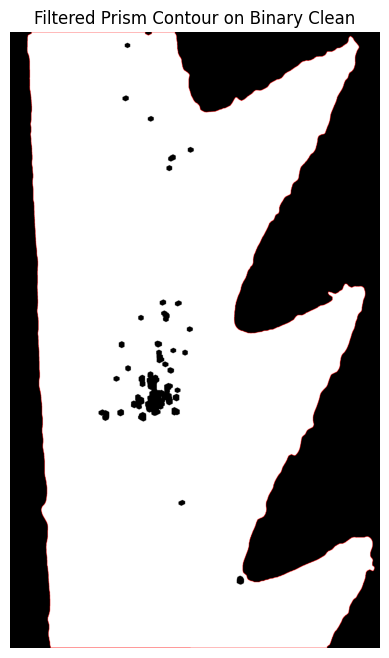

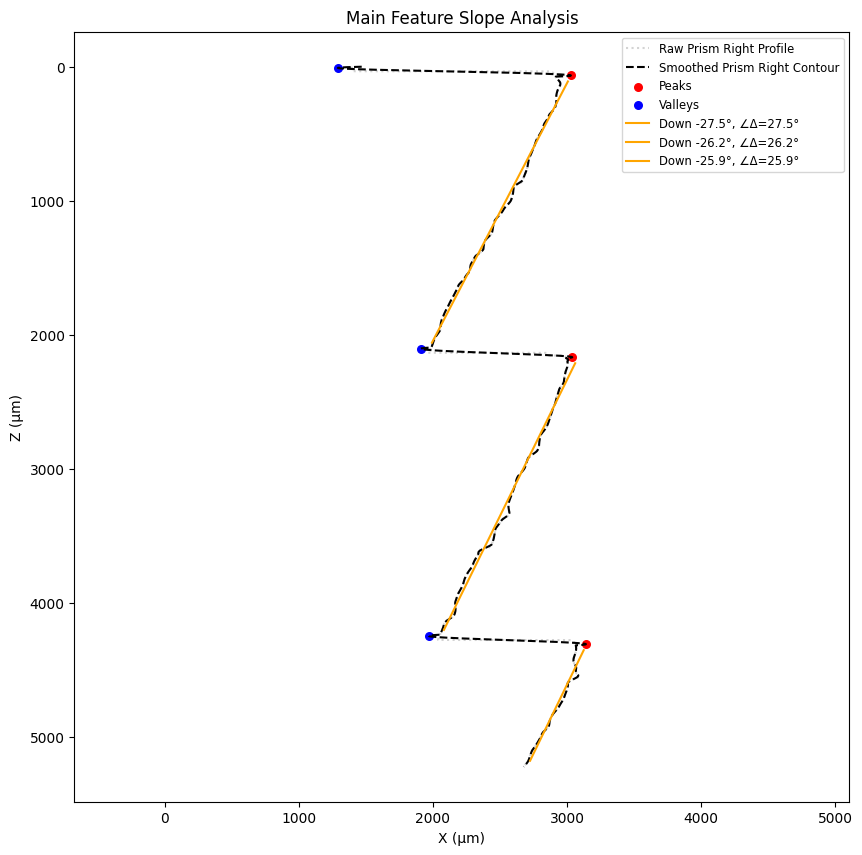


=== 斜邊角度分析 ===
Down: -27.49°, Δ=27.49°
Down: -26.21°, Δ=26.21°
Down: -25.88°, Δ=25.88°


In [49]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from math import atan2, degrees
from sklearn.linear_model import LinearRegression


def analyze_feature_slopes(
    image_path,
    px_size=1.12,
    z_scale=1.12,
    peak_prominence=50.0,
    peak_distance=200,
    fit_margin=40,
    min_r2=0.90,
):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"❌ 無法讀取影像路徑：{image_path}")
        return

    # 二值化 + 去雜訊
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    binary_clean = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=10)

    # 找外輪廓
    contours, _ = cv2.findContours(
        binary_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE
    )
    if not contours:
        print("❌ 找不到輪廓")
        return

    # 選最大輪廓
    main_contour = max(contours, key=cv2.contourArea)
    contour_points = main_contour[:, 0, :]

    # 輪廓邊界
    min_x = np.min(contour_points[:, 0])
    max_x = np.max(contour_points[:, 0])
    min_y = np.min(contour_points[:, 1])
    max_y = np.max(contour_points[:, 1])

    # 過濾基板左側 + 上下邊界
    keep_points = []
    for i in range(len(contour_points)):
        p1 = contour_points[i]
        p2 = contour_points[(i + 1) % len(contour_points)]
        dx = p2[0] - p1[0]
        dy = p2[1] - p1[1]
        angle_deg = degrees(atan2(dy, dx))
        mid_x = (p1[0] + p2[0]) / 2
        mid_y = (p1[1] + p2[1]) / 2

        if abs(mid_x - min_x) < 5 and abs(angle_deg) > 80:
            continue
        if abs(mid_y - min_y) < 5 and abs(angle_deg) < 10:
            continue
        if abs(mid_y - max_y) < 5 and abs(angle_deg) < 10:
            continue

        keep_points.append(p1)

    keep_points = np.array(keep_points).reshape(-1, 1, 2).astype(np.int32)

    # 建立稜鏡 mask
    mask_prism = np.zeros_like(binary_clean)
    cv2.drawContours(mask_prism, [keep_points], -1, 255, thickness=cv2.FILLED)

    # Debug：顯示扣除紅色三段後的輪廓
    debug_img = cv2.cvtColor(binary_clean, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(debug_img, [keep_points], -1, (0, 0, 255), 2)
    plt.figure(figsize=(6, 8))
    plt.imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
    plt.title("Filtered Prism Contour on Binary Clean")
    plt.axis("off")
    plt.show()

    # 取得稜鏡右側 profile
    profile_right_px, valid_z_indices = [], []
    H, W = mask_prism.shape
    for y in range(H):
        cols = np.where(mask_prism[y] == 255)[0]
        if len(cols) > 0:
            profile_right_px.append(cols[-1])
            valid_z_indices.append(y)

    if not valid_z_indices:
        print("❌ 找不到稜鏡右側輪廓")
        return

    # 單位轉換
    z_vals = np.array(valid_z_indices) * z_scale
    x_vals_right_raw = np.array(profile_right_px) * px_size
    x_vals_right_smoothed = savgol_filter(
        x_vals_right_raw, window_length=71, polyorder=3
    )

    # 偵測波峰/波谷
    prominence_px = peak_prominence / px_size
    peaks, _ = find_peaks(
        x_vals_right_smoothed, prominence=prominence_px, distance=peak_distance
    )
    valleys, _ = find_peaks(
        -x_vals_right_smoothed, prominence=prominence_px, distance=peak_distance
    )

    # 假設基板擬合線是垂直基準（可以另外做）
    angle_base = 0

    # 擬合段
    fitted_angles = []
    feature_points = [(p, "Peak") for p in peaks] + [(v, "Valley") for v in valleys]
    feature_points.append((0, "Start"))
    feature_points.append((len(z_vals) - 1, "End"))
    feature_points.sort(key=lambda x: x[0])

    unique_features = []
    if feature_points:
        unique_features.append(feature_points[0])
        for i in range(1, len(feature_points)):
            if feature_points[i][0] != feature_points[i - 1][0]:
                unique_features.append(feature_points[i])

    for i in range(len(unique_features) - 1):
        idx1, _ = unique_features[i]
        idx2, _ = unique_features[i + 1]
        fit_idx1, fit_idx2 = idx1 + fit_margin, idx2 - fit_margin
        if fit_idx2 <= fit_idx1 or (fit_idx2 - fit_idx1) < 20:
            continue
        z_seg = z_vals[fit_idx1 : fit_idx2 + 1]
        x_seg = x_vals_right_smoothed[fit_idx1 : fit_idx2 + 1]
        reg = LinearRegression().fit(z_seg.reshape(-1, 1), x_seg.reshape(-1, 1))
        r2 = reg.score(z_seg.reshape(-1, 1), x_seg.reshape(-1, 1))
        if r2 < min_r2:
            continue
        slope = reg.coef_[0][0]
        angle = degrees(atan2(slope, 1))
        delta = abs(angle - angle_base)
        label = "Up" if slope > 0 else "Down"
        fitted_angles.append((fit_idx1, fit_idx2, angle, label, delta))

    # 繪圖
    plt.figure(figsize=(10, 10))
    plt.plot(
        x_vals_right_raw,
        z_vals,
        label="Raw Prism Right Profile",
        color="lightgray",
        linestyle=":",
    )
    plt.plot(
        x_vals_right_smoothed,
        z_vals,
        label="Smoothed Prism Right Contour",
        color="black",
        linestyle="--",
        linewidth=1.5,
    )
    plt.scatter(
        x_vals_right_smoothed[peaks], z_vals[peaks], color="red", s=30, label="Peaks"
    )
    plt.scatter(
        x_vals_right_smoothed[valleys],
        z_vals[valleys],
        color="blue",
        s=30,
        label="Valleys",
    )
    for idx1, idx2, angle, label, delta in fitted_angles:
        z_fit = z_vals[idx1 : idx2 + 1]
        x_fit = x_vals_right_smoothed[idx1 : idx2 + 1]
        model = LinearRegression().fit(z_fit.reshape(-1, 1), x_fit.reshape(-1, 1))
        z_endpoints = z_vals[[idx1, idx2]]
        x_pred = model.predict(z_endpoints.reshape(-1, 1))
        line_color = "blue" if label == "Up" else "orange"
        plt.plot(
            x_pred,
            z_endpoints,
            linewidth=1.5,
            color=line_color,
            label=f"{label} {angle:.1f}°, ∠Δ={delta:.1f}°",
        )
    plt.xlabel("X (μm)")
    plt.ylabel("Z (μm)")
    plt.title("Main Feature Slope Analysis")
    plt.legend(fontsize="small")
    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.show()

    print("\n=== 斜邊角度分析 ===")
    for _, _, angle, label, delta in fitted_angles:
        print(f"{label}: {angle:.2f}°, Δ={delta:.2f}°")


# 範例呼叫
analyze_feature_slopes(
    r"\\140.114.141.95\nas\112\112033635_CHI\GA\0728OM\0.9_0.9\0.9_0.9_120.png",
    px_size=1.12,
    z_scale=1.12,
)

In [45]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from math import atan2, degrees
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans


def analyze_feature_slopes(
    image_path,
    px_size=1.12,
    z_scale=1.12,
    peak_prominence=50.0,
    peak_distance=200,
    fit_margin=40,
    min_r2=0.90,
):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"❌ 無法讀取影像路徑：{image_path}")
        return

    # === Step 1: 二值化 & 去雜訊 ===
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
    H, W = binary.shape

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    binary_clean = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=15)

    # === Step 2: 找外輪廓 ===
    contours, _ = cv2.findContours(
        binary_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE
    )
    if not contours:
        print("❌ 找不到外輪廓")
        return

    # === Step 3: 用 KMeans 分群基板與稜鏡 ===
    cx_list = []
    for cnt in contours:
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
        else:
            cx = 0
        cx_list.append([cx])

    kmeans = KMeans(n_clusters=2, random_state=0, n_init=10).fit(cx_list)
    labels = kmeans.labels_

    mean_x_per_cluster = [
        np.mean([cx_list[i][0] for i in range(len(cx_list)) if labels[i] == c])
        for c in range(2)
    ]
    base_cluster = np.argmin(mean_x_per_cluster)
    prism_cluster = 1 - base_cluster

    mask_base = np.zeros_like(binary)
    mask_prism = np.zeros_like(binary)
    for i, cnt in enumerate(contours):
        if labels[i] == base_cluster:
            cv2.drawContours(mask_base, [cnt], -1, 255, thickness=cv2.FILLED)
        else:
            cv2.drawContours(mask_prism, [cnt], -1, 255, thickness=cv2.FILLED)

    # === Step 4: 基板右側 profile ===
    base_right_px, base_valid_z = [], []
    for y in range(H):
        cols = np.where(mask_base[y] == 255)[0]
        if len(cols) > 0:
            base_right_px.append(cols[-1])
            base_valid_z.append(y)

    z_vals_base = np.array(base_valid_z) * z_scale
    x_vals_base_right = np.array(base_right_px) * px_size

    reg_base = LinearRegression().fit(
        z_vals_base.reshape(-1, 1), x_vals_base_right.reshape(-1, 1)
    )
    slope_base = reg_base.coef_[0][0]
    angle_base = degrees(atan2(slope_base, 1))

    # === Step 5: 稜鏡右側 profile ===
    profile_right_px, valid_z_indices = [], []
    for y in range(H):
        cols = np.where(mask_prism[y] == 255)[0]
        if len(cols) > 0:
            profile_right_px.append(cols[-1])
            valid_z_indices.append(y)

    if not valid_z_indices:
        print("❌ 找不到稜鏡輪廓")
        return

    z_vals = np.array(valid_z_indices) * z_scale
    x_vals_right_raw = np.array(profile_right_px) * px_size
    x_vals_right_smoothed = savgol_filter(
        x_vals_right_raw, window_length=71, polyorder=3
    )

    # === Step 6: 偵測波峰與波谷 ===
    prominence_px = peak_prominence / px_size
    peaks, _ = find_peaks(
        x_vals_right_smoothed, prominence=prominence_px, distance=peak_distance
    )
    valleys, _ = find_peaks(
        -x_vals_right_smoothed, prominence=prominence_px, distance=peak_distance
    )

    feature_points = [(p, "Peak") for p in peaks] + [(v, "Valley") for v in valleys]
    feature_points.append((0, "Start"))
    feature_points.append((len(z_vals) - 1, "End"))
    feature_points.sort(key=lambda x: x[0])

    unique_features = []
    if feature_points:
        unique_features.append(feature_points[0])
        for i in range(1, len(feature_points)):
            if feature_points[i][0] != feature_points[i - 1][0]:
                unique_features.append(feature_points[i])

    # === Step 7: 擬合斜邊 ===
    fitted_angles = []
    for i in range(len(unique_features) - 1):
        idx1, _ = unique_features[i]
        idx2, _ = unique_features[i + 1]
        fit_idx1, fit_idx2 = idx1 + fit_margin, idx2 - fit_margin
        if fit_idx2 <= fit_idx1 or (fit_idx2 - fit_idx1) < 20:
            continue

        z_seg = z_vals[fit_idx1 : fit_idx2 + 1]
        x_seg = x_vals_right_smoothed[fit_idx1 : fit_idx2 + 1]
        reg = LinearRegression().fit(z_seg.reshape(-1, 1), x_seg.reshape(-1, 1))
        r2 = reg.score(z_seg.reshape(-1, 1), x_seg.reshape(-1, 1))
        if r2 < min_r2:
            continue

        slope = reg.coef_[0][0]
        angle = degrees(atan2(slope, 1))
        delta = abs(angle - angle_base)
        label = "Up" if slope > 0 else "Down"
        fitted_angles.append((fit_idx1, fit_idx2, angle, label, delta))

    # === Step 8: 繪圖 ===
    plt.figure(figsize=(10, 10))
    plt.plot(
        x_vals_right_raw,
        z_vals,
        label="Raw Prism Right Profile",
        color="lightgray",
        linestyle=":",
    )
    plt.plot(
        x_vals_right_smoothed,
        z_vals,
        label="Smoothed Prism Right Contour",
        color="black",
        linestyle="--",
        linewidth=1.5,
    )
    plt.plot(
        x_vals_base_right,
        z_vals_base,
        label="Base Right Profile",
        color="green",
        alpha=0.5,
    )

    # 基板擬合線
    z_fit_base = np.linspace(z_vals_base.min(), z_vals_base.max(), 100)
    x_fit_base = reg_base.predict(z_fit_base.reshape(-1, 1))
    plt.plot(
        x_fit_base, z_fit_base, "g--", linewidth=2, label=f"Base Fit {angle_base:.1f}°"
    )

    # 特徵點
    plt.scatter(
        x_vals_right_smoothed[peaks], z_vals[peaks], color="red", s=30, label="Peaks"
    )
    plt.scatter(
        x_vals_right_smoothed[valleys],
        z_vals[valleys],
        color="blue",
        s=30,
        label="Valleys",
    )

    # 擬合線段
    for idx1, idx2, angle, label, delta in fitted_angles:
        z_fit = z_vals[idx1 : idx2 + 1]
        x_fit = x_vals_right_smoothed[idx1 : idx2 + 1]
        model = LinearRegression().fit(z_fit.reshape(-1, 1), x_fit.reshape(-1, 1))
        z_endpoints = z_vals[[idx1, idx2]]
        x_pred = model.predict(z_endpoints.reshape(-1, 1))
        line_color = "blue" if label == "Up" else "orange"
        plt.plot(
            x_pred,
            z_endpoints,
            linewidth=1.5,
            color=line_color,
            label=f"{label} {angle:.1f}°, ∠Δ={delta:.1f}°",
        )

    plt.xlabel("X (μm)")
    plt.ylabel("Z (μm)")
    plt.title("Main Feature Slope Analysis")
    plt.legend(fontsize="small")
    plt.grid(False)
    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.show()

    # === Step 9: 輸出結果 ===
    print("\n=== 基板角度 ===")
    print(f"Base angle: {angle_base:.2f}°")
    print("\n=== 斜邊角度分析 ===")
    for _, _, angle, label, delta in fitted_angles:
        print(f"{label}: {angle:.2f}°, Δ={delta:.2f}°")

analyze_feature_slopes(
    r"\\140.114.141.95\nas\112\112033635_CHI\GA\0728OM\0.9_0.9\0.9_0.9_120.png",
    px_size=1.12,
    z_scale=1.12,
)

ValueError: n_samples=1 should be >= n_clusters=2.

## success 90 deg


==================== 開始除錯分析 ====================
使用的參數: prominence=50.0, distance=250, margin=10, min_r2=0.85
偵測到的 Peaks: [1550 3305]
偵測到的 Valleys: [1866 3731]

--- 分析區段 1: 從 Start(索引 0) 到 Peak(索引 1550) ---
  -> 線性度 R-squared: 0.9990
  -> 結果: 保留

--- 分析區段 2: 從 Peak(索引 1550) 到 Valley(索引 1866) ---
  -> 線性度 R-squared: 0.9115
  -> 結果: 保留

--- 分析區段 3: 從 Valley(索引 1866) 到 Peak(索引 3305) ---
  -> 線性度 R-squared: 0.9990
  -> 結果: 保留

--- 分析區段 4: 從 Peak(索引 3305) 到 Valley(索引 3731) ---
  -> 線性度 R-squared: 0.9845
  -> 結果: 保留

--- 分析區段 5: 從 Valley(索引 3731) 到 End(索引 4314) ---
  -> 線性度 R-squared: 0.9725
  -> 結果: 保留

==================== 除錯分析結束 ====================



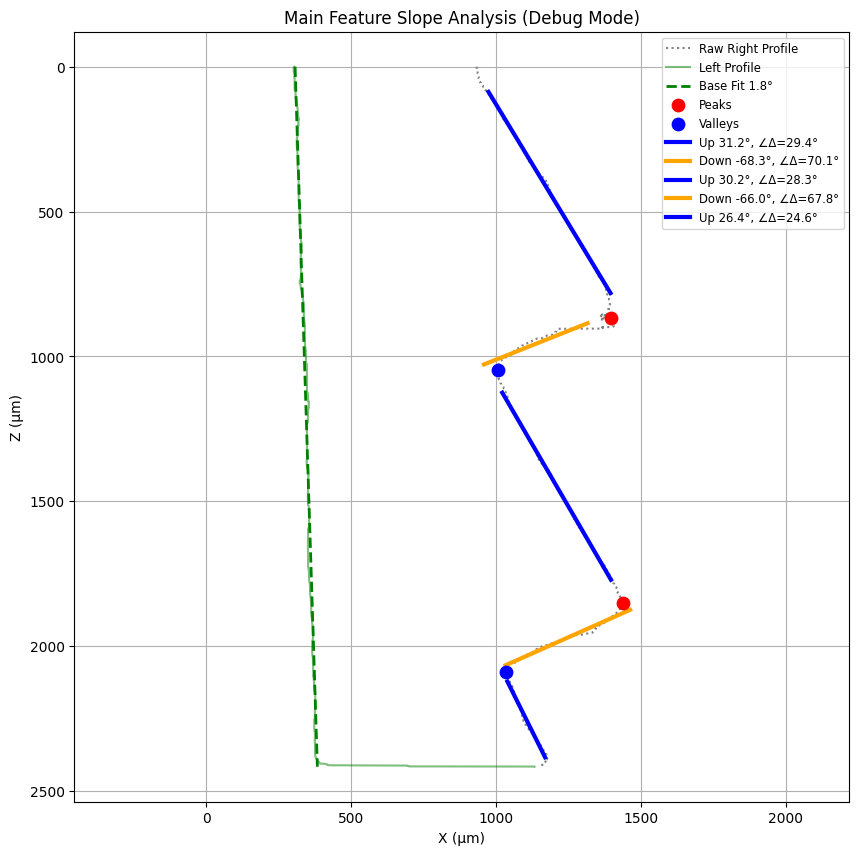


==================== 開始除錯分析 ====================
使用的參數: prominence=50.0, distance=250, margin=10, min_r2=0.85
偵測到的 Peaks: [ 829 2734]
偵測到的 Valleys: [1823]

--- 分析區段 1: 從 Start(索引 0) 到 Peak(索引 829) ---
  -> 線性度 R-squared: 0.9977
  -> 結果: 保留

--- 分析區段 2: 從 Peak(索引 829) 到 Valley(索引 1823) ---
  -> 線性度 R-squared: 0.9717
  -> 結果: 保留

--- 分析區段 3: 從 Valley(索引 1823) 到 Peak(索引 2734) ---
  -> 線性度 R-squared: 0.9937
  -> 結果: 保留

--- 分析區段 4: 從 Peak(索引 2734) 到 End(索引 3444) ---
  -> 線性度 R-squared: 0.9878
  -> 結果: 保留

==================== 除錯分析結束 ====================



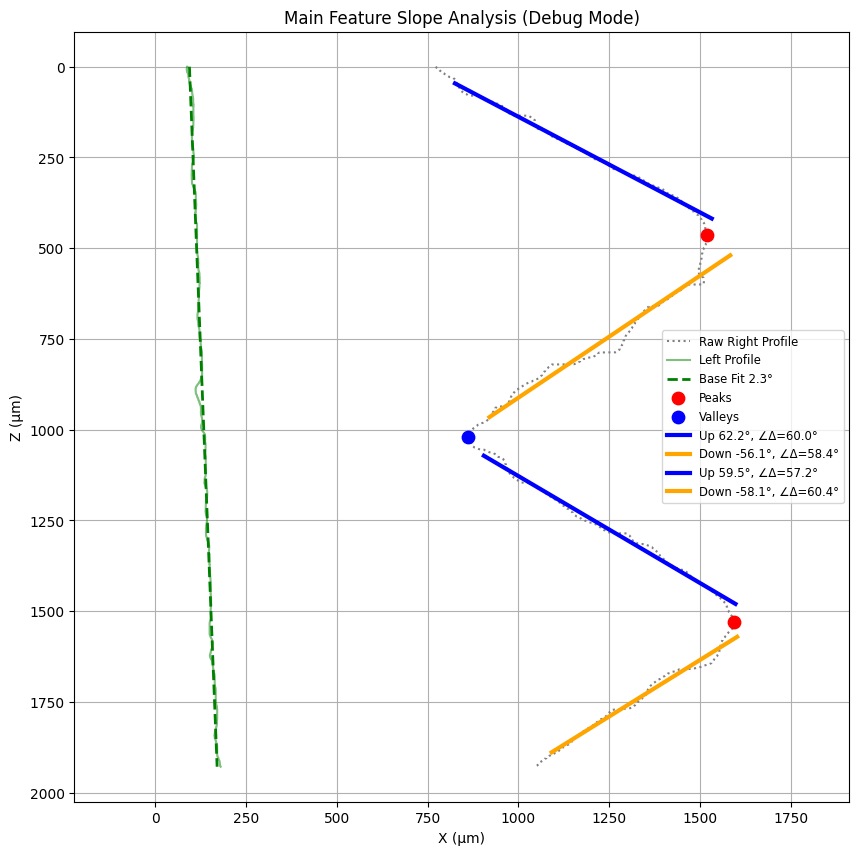


==================== 開始除錯分析 ====================
使用的參數: prominence=50.0, distance=250, margin=10, min_r2=0.85
偵測到的 Peaks: [ 829 2734]
偵測到的 Valleys: [1823]

--- 分析區段 1: 從 Start(索引 0) 到 Peak(索引 829) ---
  -> 線性度 R-squared: 0.9977
  -> 結果: 保留

--- 分析區段 2: 從 Peak(索引 829) 到 Valley(索引 1823) ---
  -> 線性度 R-squared: 0.9717
  -> 結果: 保留

--- 分析區段 3: 從 Valley(索引 1823) 到 Peak(索引 2734) ---
  -> 線性度 R-squared: 0.9937
  -> 結果: 保留

--- 分析區段 4: 從 Peak(索引 2734) 到 End(索引 3444) ---
  -> 線性度 R-squared: 0.9878
  -> 結果: 保留

==================== 除錯分析結束 ====================



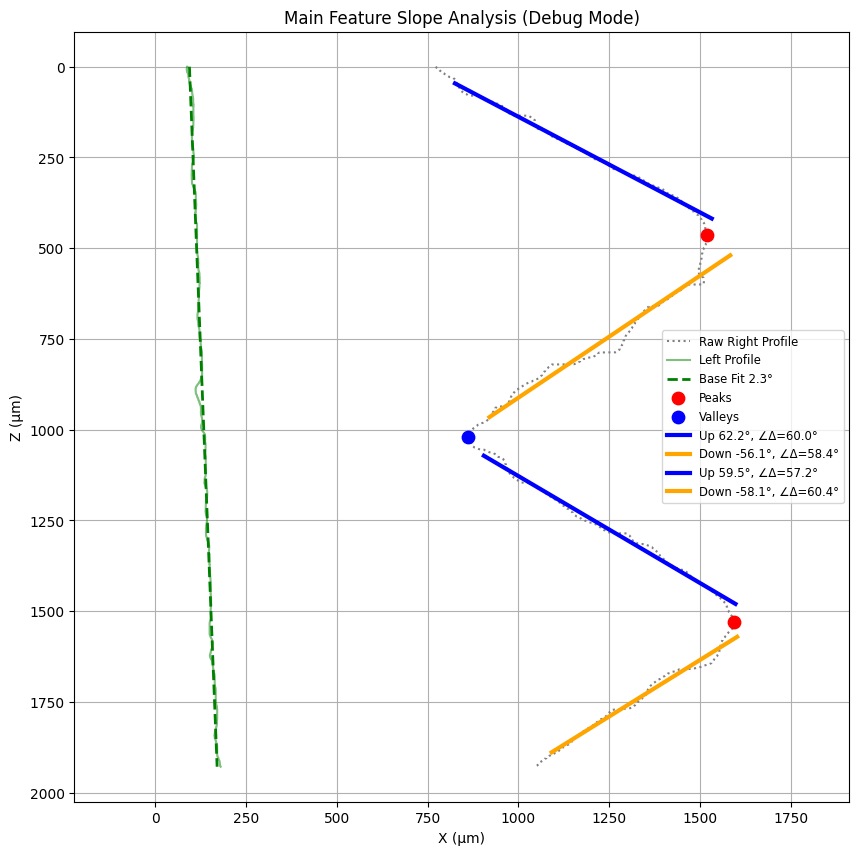


==================== 開始除錯分析 ====================
使用的參數: prominence=10.0, distance=150, margin=1, min_r2=0.55
偵測到的 Peaks: [ 294 2071]
偵測到的 Valleys: [1932 2087]

--- 分析區段 1: 從 Start(索引 0) 到 Peak(索引 294) ---
  -> 線性度 R-squared: 0.9232
  -> 結果: 保留

--- 分析區段 2: 從 Peak(索引 294) 到 Valley(索引 1932) ---
  -> 線性度 R-squared: 0.9962
  -> 結果: 保留

--- 分析區段 3: 從 Valley(索引 1932) 到 Peak(索引 2071) ---
  -> 線性度 R-squared: 0.9958
  -> 結果: 保留

--- 分析區段 4: 從 Peak(索引 2071) 到 Valley(索引 2087) ---
  -> 結果: 捨棄 (原因: 裁切邊界後線段太短)

--- 分析區段 5: 從 Valley(索引 2087) 到 End(索引 3559) ---
  -> 線性度 R-squared: 0.9997
  -> 結果: 保留

==================== 除錯分析結束 ====================



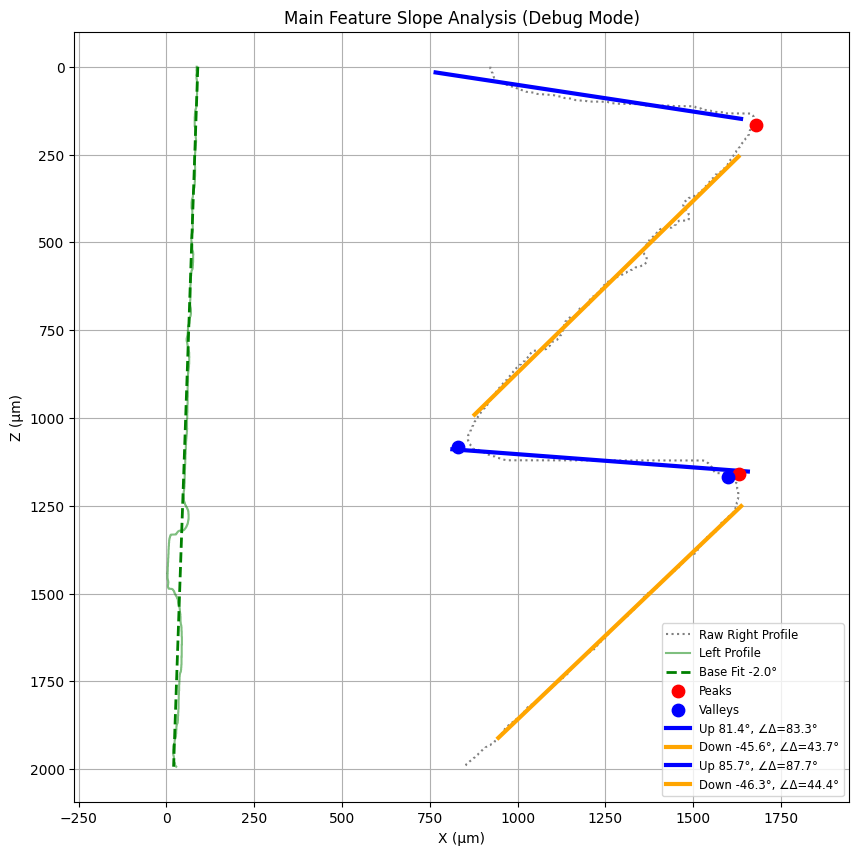


==================== 開始除錯分析 ====================
使用的參數: prominence=100.0, distance=650, margin=1, min_r2=0.85
偵測到的 Peaks: [987]
偵測到的 Valleys: [1712]

--- 分析區段 1: 從 Start(索引 0) 到 Peak(索引 987) ---
  -> 線性度 R-squared: 0.9873
  -> 結果: 保留

--- 分析區段 2: 從 Peak(索引 987) 到 Valley(索引 1712) ---
  -> 線性度 R-squared: 0.9970
  -> 結果: 保留

--- 分析區段 3: 從 Valley(索引 1712) 到 End(索引 2512) ---
  -> 線性度 R-squared: 0.9939
  -> 結果: 保留

==================== 除錯分析結束 ====================



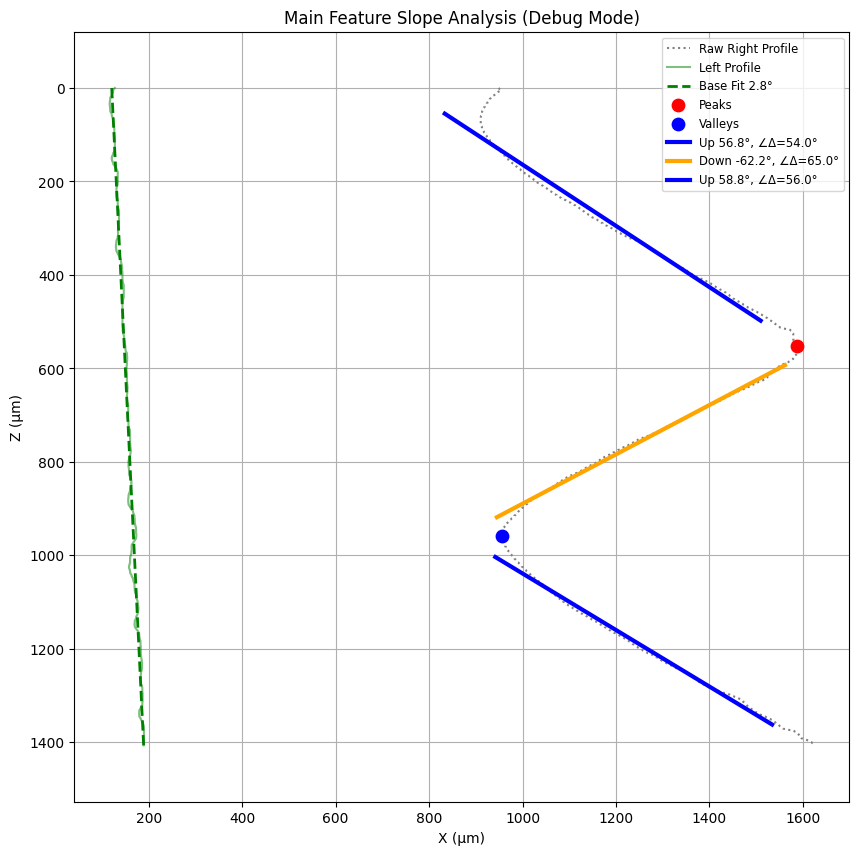


==================== 開始除錯分析 ====================
使用的參數: prominence=100.0, distance=650, margin=1, min_r2=0.85
偵測到的 Peaks: [ 910 2507]
偵測到的 Valleys: [1582]

--- 分析區段 1: 從 Start(索引 0) 到 Peak(索引 910) ---
  -> 線性度 R-squared: 0.9954
  -> 結果: 保留

--- 分析區段 2: 從 Peak(索引 910) 到 Valley(索引 1582) ---
  -> 線性度 R-squared: 0.9927
  -> 結果: 保留

--- 分析區段 3: 從 Valley(索引 1582) 到 Peak(索引 2507) ---
  -> 線性度 R-squared: 0.9952
  -> 結果: 保留

--- 分析區段 4: 從 Peak(索引 2507) 到 End(索引 3345) ---
  -> 線性度 R-squared: 0.9619
  -> 結果: 保留

==================== 除錯分析結束 ====================



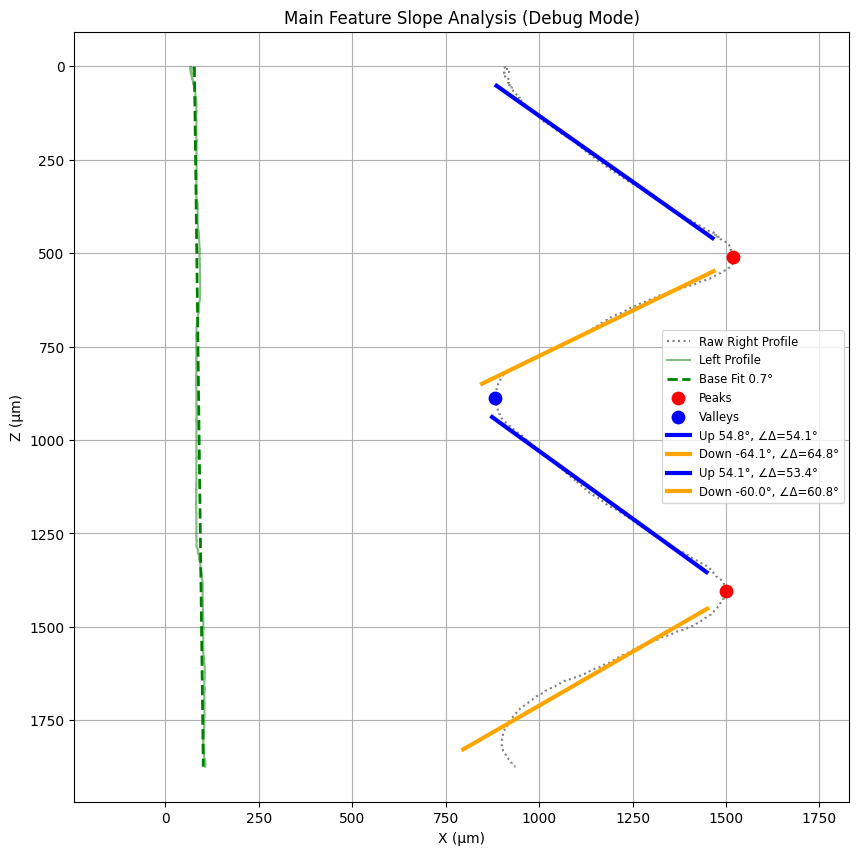


==================== 開始除錯分析 ====================
使用的參數: prominence=50.0, distance=250, margin=10, min_r2=0.85
偵測到的 Peaks: [  92 1968 3878]
偵測到的 Valleys: [1837 3746]

--- 分析區段 1: 從 Start(索引 0) 到 Peak(索引 92) ---
  -> 線性度 R-squared: 0.9831
  -> 結果: 保留

--- 分析區段 2: 從 Peak(索引 92) 到 Valley(索引 1837) ---
  -> 線性度 R-squared: 0.9957
  -> 結果: 保留

--- 分析區段 3: 從 Valley(索引 1837) 到 Peak(索引 1968) ---
  -> 線性度 R-squared: 0.9957
  -> 結果: 保留

--- 分析區段 4: 從 Peak(索引 1968) 到 Valley(索引 3746) ---
  -> 線性度 R-squared: 0.9923
  -> 結果: 保留

--- 分析區段 5: 從 Valley(索引 3746) 到 Peak(索引 3878) ---
  -> 線性度 R-squared: 0.9954
  -> 結果: 保留

--- 分析區段 6: 從 Peak(索引 3878) 到 End(索引 4650) ---
  -> 線性度 R-squared: 0.9860
  -> 結果: 保留

==================== 除錯分析結束 ====================



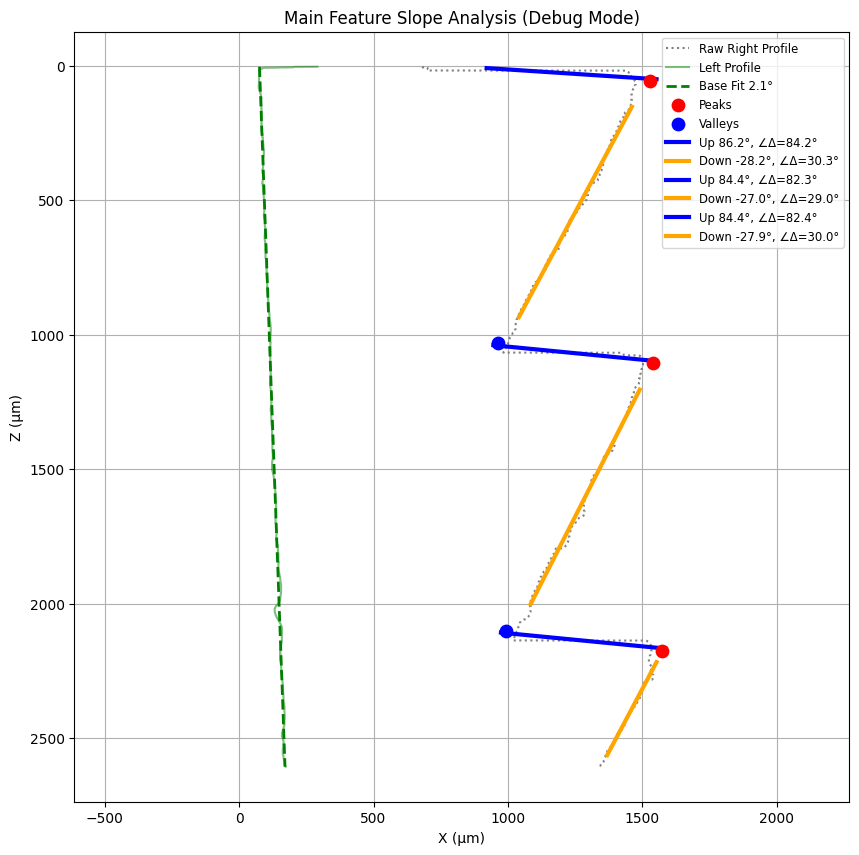

In [176]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from math import atan2, degrees
from sklearn.linear_model import LinearRegression


def analyze_feature_slopes_debug(
    image_path,
    px_size=1.12,
    z_scale=1.12,
    peak_prominence=50.0,
    peak_distance=200,
    fit_margin=40,
    min_r2=0.90,
):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"錯誤：無法讀取影像路徑 {image_path}")
        return

    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
    H, W = binary.shape

    profile_left_px, profile_right_px, valid_z_indices = [], [], []
    for y in range(H):
        cols = np.where(binary[y] == 255)[0]
        if len(cols) > 0:
            profile_left_px.append(cols[0])
            profile_right_px.append(cols[-1])
            valid_z_indices.append(y)

    if not valid_z_indices:
        print("在影像中未偵測到輪廓。")
        return

    z_vals = np.array(valid_z_indices) * z_scale
    x_vals_left = np.array(profile_left_px) * px_size
    x_vals_right_raw = np.array(profile_right_px) * px_size

    # --- 【修改點 1】修正濾波器的邊界處理模式 ---
    x_vals_right_smoothed = savgol_filter(
        x_vals_right_raw,
        window_length=171,
        polyorder=3,
        mode="mirror",  # window_length=101
    )

    reg_base = LinearRegression().fit(z_vals.reshape(-1, 1), x_vals_left.reshape(-1, 1))
    slope_base = reg_base.coef_[0][0]
    angle_base = degrees(atan2(slope_base, 1))

    prominence_px = peak_prominence / px_size
    peaks, p_props = find_peaks(
        x_vals_right_smoothed, prominence=prominence_px, distance=peak_distance
    )
    valleys, v_props = find_peaks(
        -x_vals_right_smoothed, prominence=prominence_px, distance=peak_distance
    )

    feature_points = [(p, "Peak") for p in peaks] + [(v, "Valley") for v in valleys]
    feature_points.append((0, "Start"))
    feature_points.append((len(z_vals) - 1, "End"))
    feature_points.sort(key=lambda x: x[0])

    unique_features = []
    if feature_points:
        unique_features.append(feature_points[0])
        for i in range(1, len(feature_points)):
            if feature_points[i][0] != feature_points[i - 1][0]:
                unique_features.append(feature_points[i])

    # --- 【修改點 2】加入詳細的除錯日誌 ---
    print("\n" + "=" * 20 + " 開始除錯分析 " + "=" * 20)
    print(
        f"使用的參數: prominence={peak_prominence}, distance={peak_distance}, margin={fit_margin}, min_r2={min_r2}"
    )
    print(f"偵測到的 Peaks: {peaks}")
    print(f"偵測到的 Valleys: {valleys}\n")

    fitted_angles = []
    for i in range(len(unique_features) - 1):
        idx1, label1 = unique_features[i]
        idx2, label2 = unique_features[i + 1]

        print(
            f"--- 分析區段 {i+1}: 從 {label1}(索引 {idx1}) 到 {label2}(索引 {idx2}) ---"
        )

        segment_length = idx2 - idx1
        # 將 margin 設定為線段長度的特定比例，例如 25%
        # 這裡的 0.25 (即25%) 是一個可以調整的超參數
        adaptive_margin = int(segment_length * 0.1)
        
        # 使用適應性 margin 進行裁切
        fit_idx1, fit_idx2 = idx1 + adaptive_margin, idx2 - adaptive_margin

        if fit_idx2 <= fit_idx1 or (fit_idx2 - fit_idx1) < 20:
            print(f"  -> 結果: 捨棄 (原因: 裁切邊界後線段太短)\n")
            continue

        z_seg = z_vals[fit_idx1 : fit_idx2 + 1]
        x_seg = x_vals_right_smoothed[fit_idx1 : fit_idx2 + 1]

        reg = LinearRegression().fit(z_seg.reshape(-1, 1), x_seg.reshape(-1, 1))
        r2 = reg.score(z_seg.reshape(-1, 1), x_seg.reshape(-1, 1))
    

        print(f"  -> 線性度 R-squared: {r2:.4f}")

        if r2 < min_r2:
            print(f"  -> 結果: 捨棄 (原因: 線性度 {r2:.4f} < 門檻 {min_r2})\n")
            continue

        print(f"  -> 結果: 保留\n")
        slope = reg.coef_[0][0]
        angle = degrees(atan2(slope, 1))
        delta = abs(angle - angle_base)
        label = "Up" if slope > 0 else "Down"
        fitted_angles.append((fit_idx1, fit_idx2, angle, label, delta))

    print("=" * 20 + " 除錯分析結束 " + "=" * 20 + "\n")

    # --- 繪圖步驟 (維持不變) ---
    plt.figure(figsize=(10, 10))
    # ... (此處繪圖代碼與前一版完全相同，故省略) ...
    plt.plot(
        x_vals_right_raw,
        z_vals,
        label="Raw Right Profile",
        color= "gray",#"lightgray",
        linestyle=":",
    )
    # plt.plot(
    #     x_vals_right_smoothed,
    #     z_vals,
    #     label="Smoothed Right Contour",
    #     color="black",
    #     linestyle="--",
    #     linewidth=1.5,
    # )
    plt.plot(x_vals_left, z_vals, label="Left Profile", color="green", alpha=0.5)
    z_fit_base = np.linspace(z_vals.min(), z_vals.max(), 100)
    x_fit_base = reg_base.predict(z_fit_base.reshape(-1, 1))
    plt.plot(
        x_fit_base, z_fit_base, "g--", linewidth=2, label=f"Base Fit {angle_base:.1f}°"
    )
    plt.scatter(
        x_vals_right_smoothed[peaks],
        z_vals[peaks],
        color="red",
        s=80,
        zorder=5,
        label="Peaks",
    )
    plt.scatter(
        x_vals_right_smoothed[valleys],
        z_vals[valleys],
        color="blue",
        s=80,
        zorder=5,
        label="Valleys",
    )
    for idx1, idx2, angle, label, delta in fitted_angles:
        z_fit = z_vals[idx1 : idx2 + 1]
        model = LinearRegression().fit(
            z_fit.reshape(-1, 1), x_vals_right_smoothed[idx1 : idx2 + 1].reshape(-1, 1)
        )
        z_endpoints = z_vals[[idx1, idx2]]
        x_pred = model.predict(z_endpoints.reshape(-1, 1))
        line_color = "blue" if label == "Up" else "orange"
        plt.plot(
            x_pred,
            z_endpoints,
            linewidth=3,
            color=line_color,
            label=f"{label} {angle:.1f}°, ∠Δ={delta:.1f}°",
        )
    plt.xlabel("X (μm)")
    plt.ylabel("Z (μm)")
    plt.title("Main Feature Slope Analysis (Debug Mode)")
    plt.legend(fontsize="small")
    plt.grid(True)
    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.show()


# --- 如何執行 ---

# 1. 先用一組相對合理的參數來執行
# 2. 查看下方 Console 印出的除錯日誌
# 3. 根據日誌，找出頂部斜邊被捨棄的原因 (例如 R-squared 太低)，然後針對性地微調參數

analyze_feature_slopes_debug(
    image_path=
    r"\\140.114.141.95\nas\112\112033635_CHI\GA\0728OM\0.9_0.9\0.9_0.9_30_clean.png",
    px_size=0.56,
    z_scale=0.56,
    peak_prominence=50.0,  # 建議先從一個較高但非極端的值開始
    peak_distance=250,
    fit_margin=10,
    min_r2=0.85,  # 建議先用一個較寬鬆的 R-squared
)
analyze_feature_slopes_debug(
    image_path=
    r"\\140.114.141.95\nas\112\112033635_CHI\GA\0728OM\0.9_0.9\0.9_0.9_60_clean.png",
    # r"\\140.114.141.95\nas\112\112033635_CHI\GA\0728OM\0.9_0.9\0.9_0.9_90_clean.png",
    px_size=0.56,
    z_scale=0.56,
    peak_prominence=50.0,  # 建議先從一個較高但非極端的值開始
    peak_distance=250,
    fit_margin=10,
    min_r2=0.85,  # 建議先用一個較寬鬆的 R-squared
)

analyze_feature_slopes_debug(
    image_path=r"\\140.114.141.95\nas\112\112033635_CHI\GA\0728OM\0.9_0.9\0.9_0.9_60_clean.png",
    # r"\\140.114.141.95\nas\112\112033635_CHI\GA\0728OM\0.9_0.9\0.9_0.9_90_clean.png",
    px_size=0.56,
    z_scale=0.56,
    peak_prominence=50.0,  # 建議先從一個較高但非極端的值開始
    peak_distance=250,
    fit_margin=10,
    min_r2=0.85,  # 建議先用一個較寬鬆的 R-squared
)

analyze_feature_slopes_debug(
    image_path=
    # r"\\140.114.141.95\nas\112\112033635_CHI\GA\0728OM\0.9_0.9\0.9_0.9_90_clean.png",
    r"\\140.114.141.95\nas\112\112033635_CHI\GA\0728OM\0.9_0.9\0.9_0.9_90_02_clean_rotate.png",
    px_size=0.56,
    z_scale=0.56,
    peak_prominence=10.0,  # 建議先從一個較高但非極端的值開始
    peak_distance=150,
    fit_margin=1,
    min_r2=0.55,  # 建議先用一個較寬鬆的 R-squared
)

analyze_feature_slopes_debug(
    image_path=r"C:\Users\cchih\Desktop\NTHU\MasterThesis\research_log\202507\0728\0.76_0.9_59_clean.png",
    px_size=0.56,
    z_scale=0.56,
    peak_prominence=100.0,  # 建議先從一個較高但非極端的值開始
    peak_distance=650,
    fit_margin=1,
    min_r2=0.85,  # 建議先用一個較寬鬆的 R-squared
)

analyze_feature_slopes_debug(
    image_path=r"\\140.114.141.95\nas\112\112033635_CHI\GA\0729OM\0.76_0.9_59_binary02_crop_clean.png",
    px_size=0.56,
    z_scale=0.56,
    peak_prominence=100.0,  # 建議先從一個較高但非極端的值開始
    peak_distance=650,
    fit_margin=1,
    min_r2=0.85,  # 建議先用一個較寬鬆的 R-squared
)

analyze_feature_slopes_debug(
    image_path=r"C:\Users\cchih\Desktop\NTHU\MasterThesis\research_log\202508\0801\0.9_0.9\0.9_0.9_120.png",
    # r"\\140.114.141.95\nas\112\112033635_CHI\GA\0728OM\0.9_0.9\0.9_0.9_90_clean.png",
    px_size=0.56,
    z_scale=0.56,
    peak_prominence=50.0,  # 建議先從一個較高但非極端的值開始
    peak_distance=250,
    fit_margin=10,
    min_r2=0.85,  # 建議先用一個較寬鬆的 R-squared
)

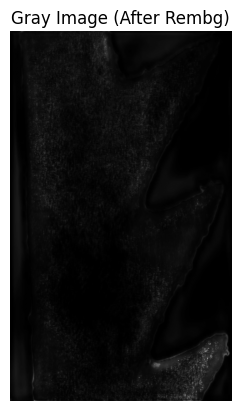

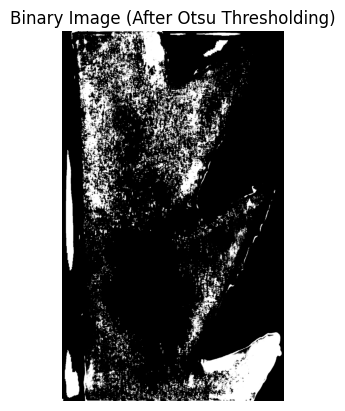

In [9]:
from rembg import remove
from PIL import Image
import numpy as np
import cv2
import io
import matplotlib.pyplot as plt

def load_image_with_removed_background(image_path):
    # 開啟原始圖片（PIL 格式）
    input_image = Image.open(image_path).convert("RGBA")

    # 去背（輸出為 RGBA PNG）
    output_image = remove(input_image)

    # 將 RGBA 轉為灰階，使用 alpha channel 做遮罩
    image_np = np.array(output_image)

    if image_np.shape[2] == 4:
        # 利用 Alpha channel 作為 foreground mask
        alpha_channel = image_np[:, :, 3]
        gray_foreground = cv2.cvtColor(image_np[:, :, :3], cv2.COLOR_RGB2GRAY)
        # 只保留非透明處（前景）
        gray_masked = cv2.bitwise_and(
            gray_foreground, gray_foreground, mask=alpha_channel
        )
    else:
        gray_masked = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)

    return gray_masked


def binarize_image(gray_image):
    # 用 Otsu 做自動二值化
    _, binary = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return binary


# === 主流程 ===
image_path = r"\\140.114.141.95\nas\112\112033635_CHI\GA\0728OM\0.9_0.9\0.9_0.9_120.png"

# Step 1: 去背後轉灰階
gray_no_bg = load_image_with_removed_background(image_path)
plt.imshow(gray_no_bg, cmap='gray')
plt.title("Gray Image (After Rembg)")   
plt.axis('off')
plt.show()
# Step 2: 再二值化處理
binary = binarize_image(gray_no_bg)
plt.imshow(binary, cmap='gray')
plt.title("Binary Image (After Otsu Thresholding)")
plt.axis('off')
plt.show()

# # 顯示結果
# cv2.imshow("Binary (After Rembg)", binary)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

## GENERALIZATION

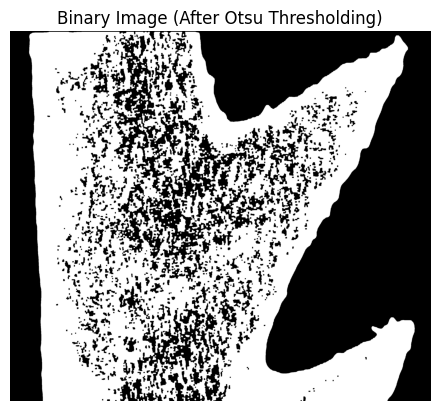

window_length: 73

📂 處理檔案: 0.9_0.9_120.png
參數: prominence=43.24, distance=137, margin_ratio=0.15


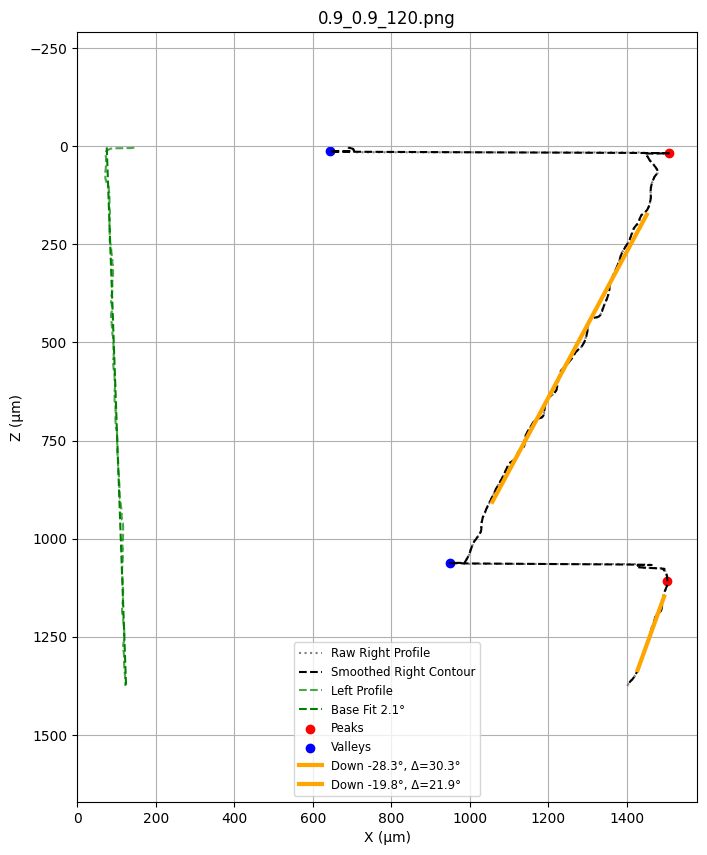

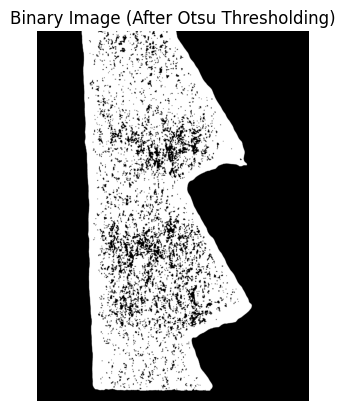

window_length: 129

📂 處理檔案: 0.9_0.9_30_clean.png
參數: prominence=25.43, distance=241, margin_ratio=0.15


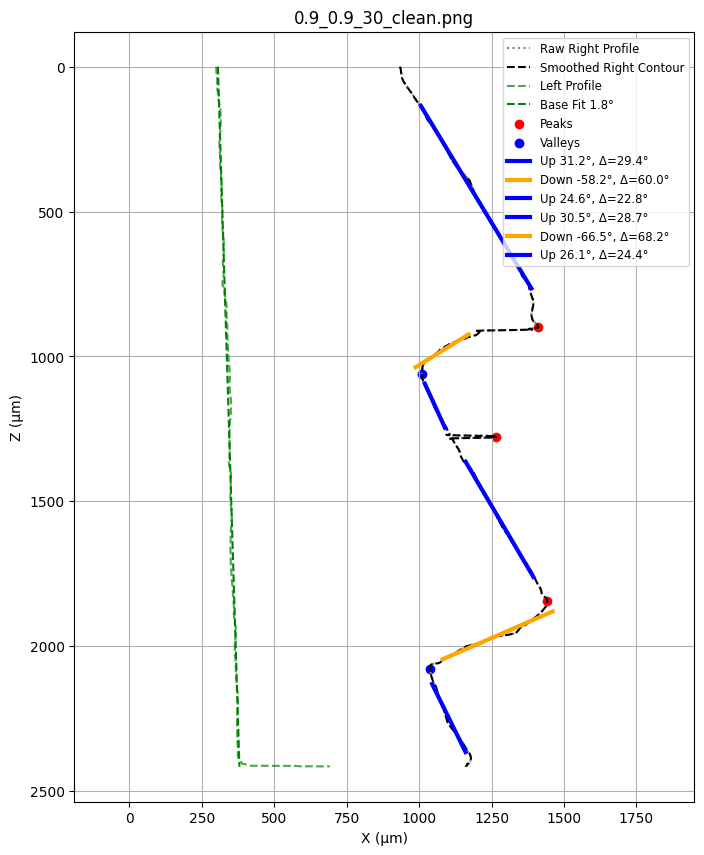

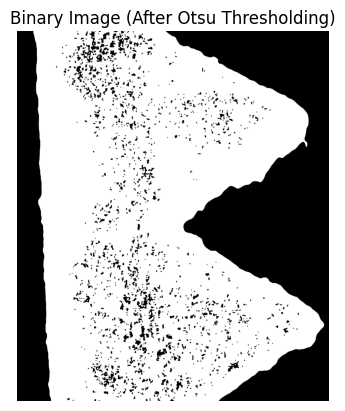

window_length: 103

📂 處理檔案: 0.9_0.9_60_clean.png
參數: prominence=41.31, distance=192, margin_ratio=0.15


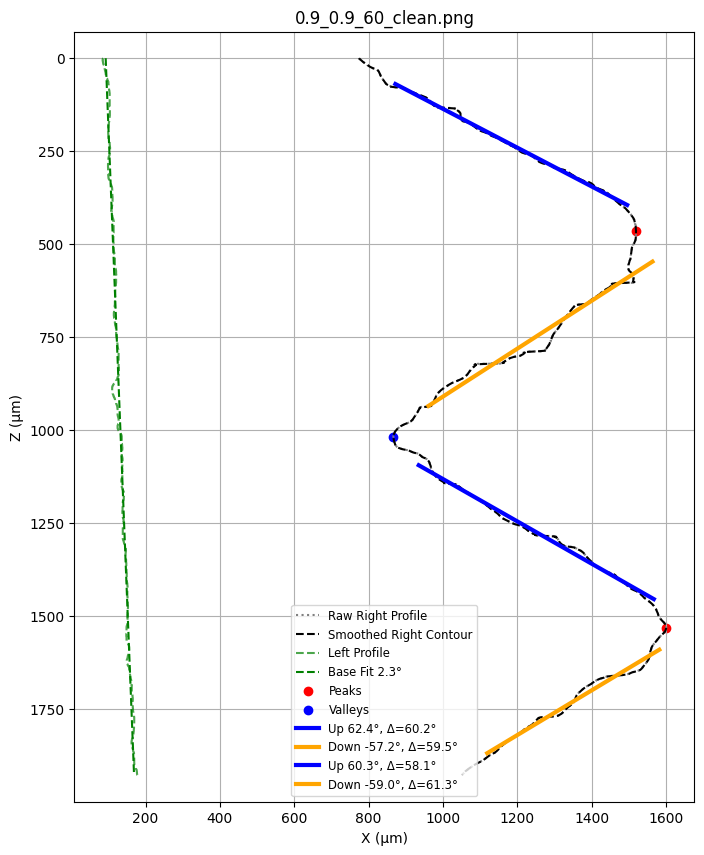

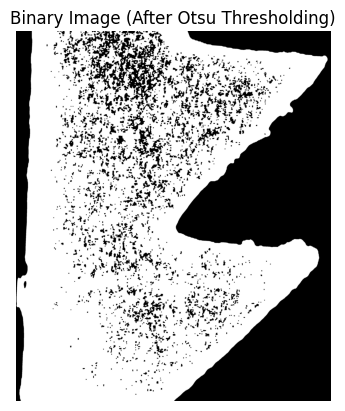

window_length: 107

📂 處理檔案: 0.9_0.9_90_02_clean_rotate.png
參數: prominence=41.30, distance=199, margin_ratio=0.15


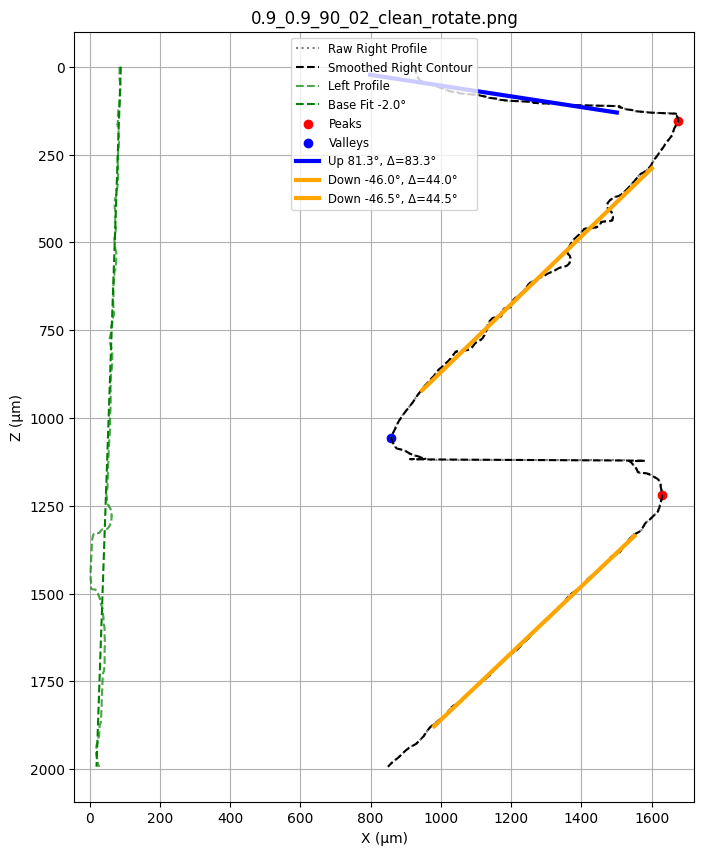

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from math import atan2, degrees
from sklearn.linear_model import LinearRegression
import os
from skimage.restoration import denoise_tv_chambolle

def analyze_feature_slopes_auto(
    image_path,
    px_size=0.56,
    z_scale=0.56,
    base_prominence_ratio=0.05,  # x方向變化量比例
    base_distance_ratio=0.1,  # z高度比例
    min_segment_points=20,
    adaptive_margin_ratio=0.15,  # segment margin
    r2_tiers=(0.95, 0.90, 0.85),  # 對應長度階層的r²門檻
):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"❌ 錯誤：無法讀取影像路徑 {image_path}")
        return

    # _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    plt.imshow(binary, cmap="gray")
    plt.title("Binary Image (After Otsu Thresholding)")
    plt.axis('off')
    plt.show()
    H, W = binary.shape

    profile_left_px, profile_right_px, valid_z_indices = [], [], []
    for y in range(H):
        cols = np.where(binary[y] == 255)[0]
        if len(cols) > 0:
            profile_left_px.append(cols[0])
            profile_right_px.append(cols[-1])
            valid_z_indices.append(y)

    if not valid_z_indices:
        print("❌ 無有效輪廓")
        return

    z_vals = np.array(valid_z_indices) * z_scale
    x_vals_left = np.array(profile_left_px) * px_size
    x_vals_right_raw = np.array(profile_right_px) * px_size

    raw_len = len(x_vals_right_raw)
    target_ratio = 0.03  # 或 0.03 ~ 0.1 看你圖的鋸齒程度
    estimated_window = int(raw_len * target_ratio)
    if estimated_window % 2 == 0:
        estimated_window += 1
    window_length = max(11, min(estimated_window, 201))

    # 平滑右側 profile
    # x_tv = denoise_tv_chambolle(x_vals_right_raw, weight=0.1)
    # x_vals_right_smoothed = savgol_filter(x_tv, window_length=81, polyorder=2)
    x_vals_right_smoothed = savgol_filter(
        x_vals_right_raw,
        window_length=11,
        #window_length=min(171, len(x_vals_right_raw) // 2 * 2 + 1),
        polyorder=3,
        mode="mirror",
    )

    print(f"window_length: {window_length}")

    # 基底線擬合
    reg_base = LinearRegression().fit(z_vals.reshape(-1, 1), x_vals_left.reshape(-1, 1))
    slope_base = reg_base.coef_[0][0]
    angle_base = degrees(atan2(slope_base, 1))

    # === 自動參數化 ===
    x_range = np.max(x_vals_right_smoothed) - np.min(x_vals_right_smoothed)
    z_range = np.max(z_vals) - np.min(z_vals)
    peak_prominence = x_range * base_prominence_ratio
    peak_distance = int(z_range * base_distance_ratio)

    peaks, _ = find_peaks(
        x_vals_right_smoothed, prominence=peak_prominence, distance=peak_distance
    )
    valleys, _ = find_peaks(
        -x_vals_right_smoothed, prominence=peak_prominence, distance=peak_distance
    )

    feature_points = [(p, "Peak") for p in peaks] + [(v, "Valley") for v in valleys]
    feature_points.append((0, "Start"))
    feature_points.append((len(z_vals) - 1, "End"))
    feature_points = sorted(set(feature_points), key=lambda x: x[0])

    fitted_angles = []
    print(f"\n📂 處理檔案: {os.path.basename(image_path)}")
    print(
        f"參數: prominence={peak_prominence:.2f}, distance={peak_distance}, margin_ratio={adaptive_margin_ratio}"
    )

    for i in range(len(feature_points) - 1):
        idx1, label1 = feature_points[i]
        idx2, label2 = feature_points[i + 1]
        segment_length = idx2 - idx1
        if segment_length < min_segment_points:
            continue

        fit_idx1 = idx1 + int(segment_length * adaptive_margin_ratio)
        fit_idx2 = idx2 - int(segment_length * adaptive_margin_ratio)
        if fit_idx2 <= fit_idx1:
            continue

        z_seg = z_vals[fit_idx1 : fit_idx2 + 1]
        # x_seg = x_vals_right_smoothed[fit_idx1 : fit_idx2 + 1]
        x_seg = x_vals_right_raw[fit_idx1 : fit_idx2 + 1]
        reg = LinearRegression().fit(z_seg.reshape(-1, 1), x_seg.reshape(-1, 1))
        r2 = reg.score(z_seg.reshape(-1, 1), x_seg.reshape(-1, 1))

        # === 適應性 r2 門檻 ===
        if segment_length < 60:
            min_r2 = r2_tiers[0]
        elif segment_length < 150:
            min_r2 = r2_tiers[1]
        else:
            min_r2 = r2_tiers[2]

        if r2 >= min_r2:
            slope = reg.coef_[0][0]
            angle = degrees(atan2(slope, 1))
            delta = abs(angle - angle_base)
            label = "Up" if slope > 0 else "Down"
            fitted_angles.append((fit_idx1, fit_idx2, angle, label, delta))

    # === 繪圖 ===
    plt.figure(figsize=(8, 10))
    plt.plot(x_vals_right_raw, z_vals, ":", color="gray", label="Raw Right Profile")
    plt.plot(
        x_vals_right_smoothed,
        z_vals,
        "--",
        color="black",
        label="Smoothed Right Contour",
        linewidth=1.5,
    )
    plt.plot(x_vals_left, z_vals, "g--", label="Left Profile", alpha=0.7)

    x_fit_base = reg_base.predict(z_vals.reshape(-1, 1))
    plt.plot(x_fit_base, z_vals, "g--", label=f"Base Fit {angle_base:.1f}°")

    plt.scatter(x_vals_right_smoothed[peaks], z_vals[peaks], color="red", label="Peaks")
    plt.scatter(
        x_vals_right_smoothed[valleys], z_vals[valleys], color="blue", label="Valleys"
    )

    for idx1, idx2, angle, label, delta in fitted_angles:
        z_endpoints = z_vals[[idx1, idx2]]
        model = LinearRegression().fit(
            z_vals[idx1 : idx2 + 1].reshape(-1, 1),
            x_vals_right_smoothed[idx1 : idx2 + 1].reshape(-1, 1),
            #x_vals_right_raw[idx1 : idx2 + 1].reshape(-1, 1),
        )
        x_pred = model.predict(z_endpoints.reshape(-1, 1))
        # x_pred = reg.predict(z_endpoints.reshape(-1, 1))
        color = "blue" if label == "Up" else "orange"
        plt.plot(
            x_pred,
            z_endpoints,
            linewidth=3,
            color=color,
            label=f"{label} {angle:.1f}°, Δ={delta:.1f}°",
        )

    plt.xlabel("X (μm)")
    plt.ylabel("Z (μm)")
    plt.legend(fontsize="small")
    plt.grid(True)
    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.title(os.path.basename(image_path))
    plt.show()

image_folder = r"C:\Users\cchih\Desktop\NTHU\MasterThesis\research_log\202508\0801\RemoveBackground"
for file in os.listdir(image_folder):
    if file.endswith(".png"):
        image_path = os.path.join(image_folder, file)
        analyze_feature_slopes_auto(image_path)

## 更新 profile 擷取段

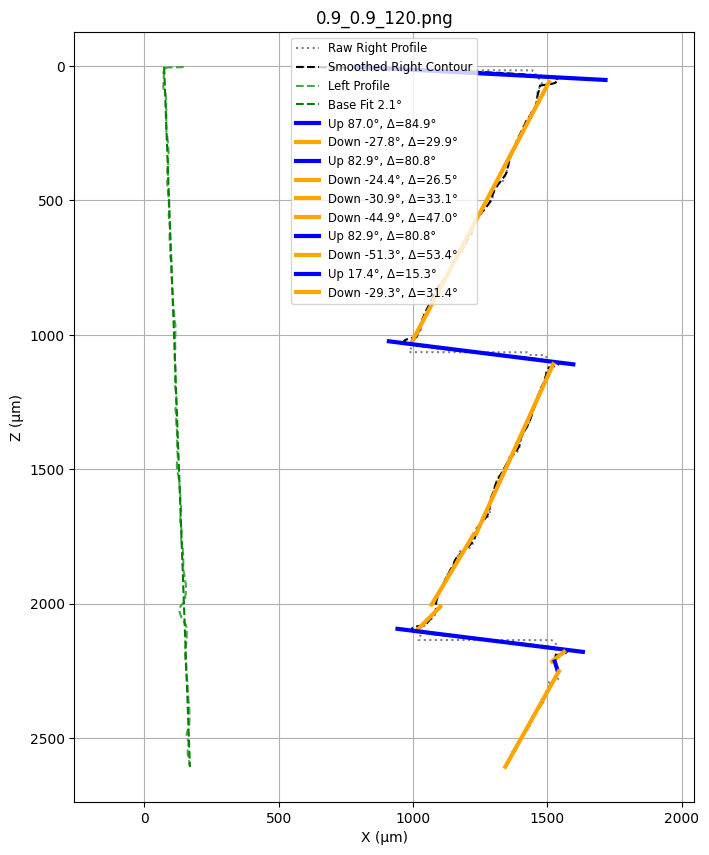

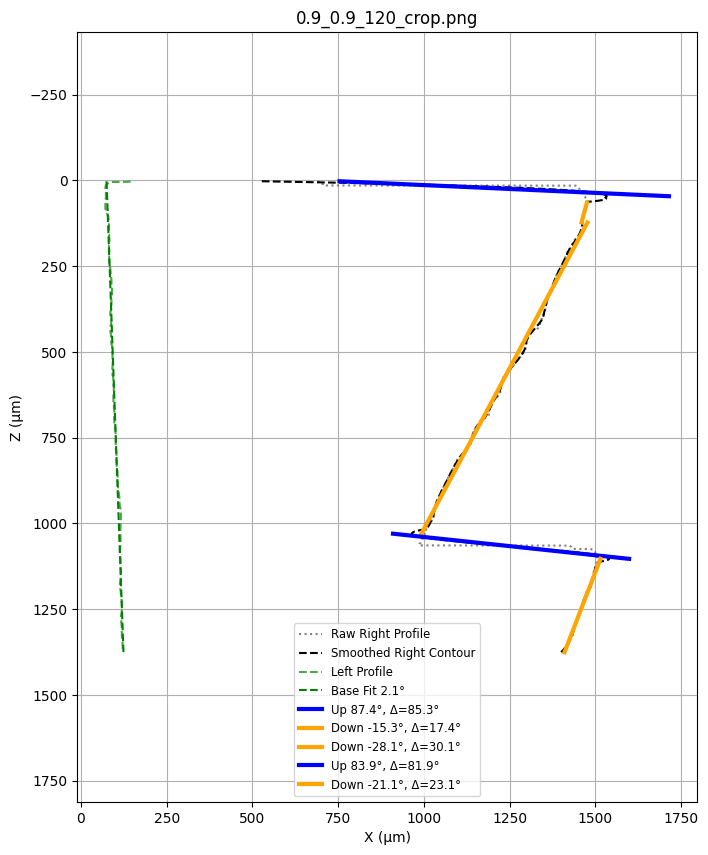

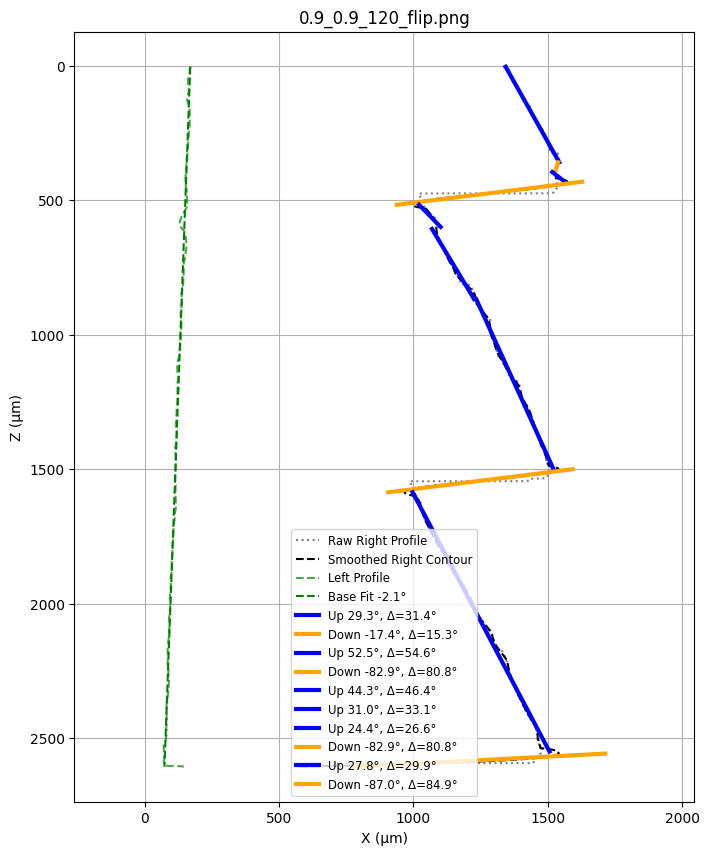

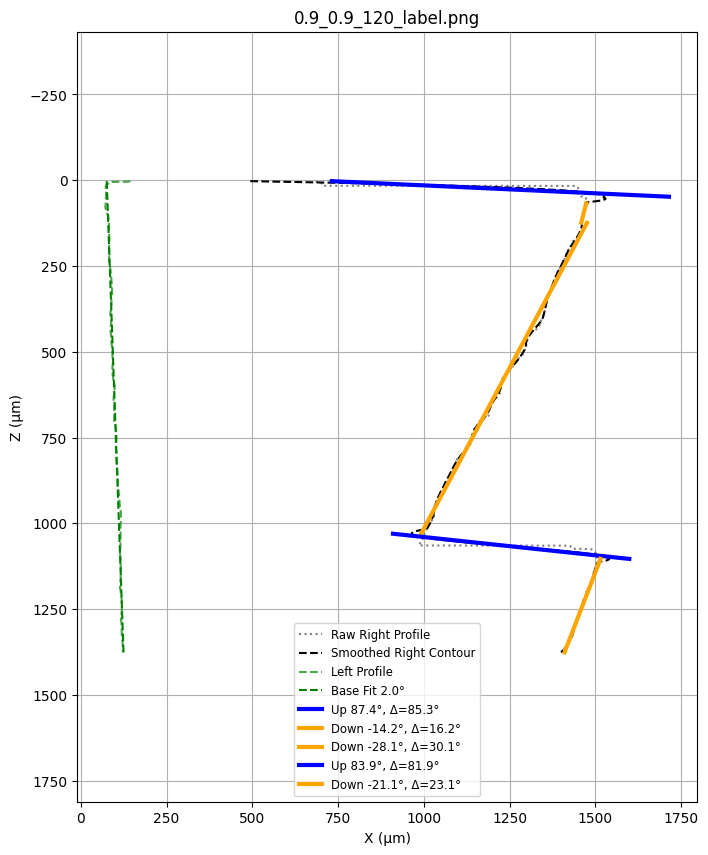

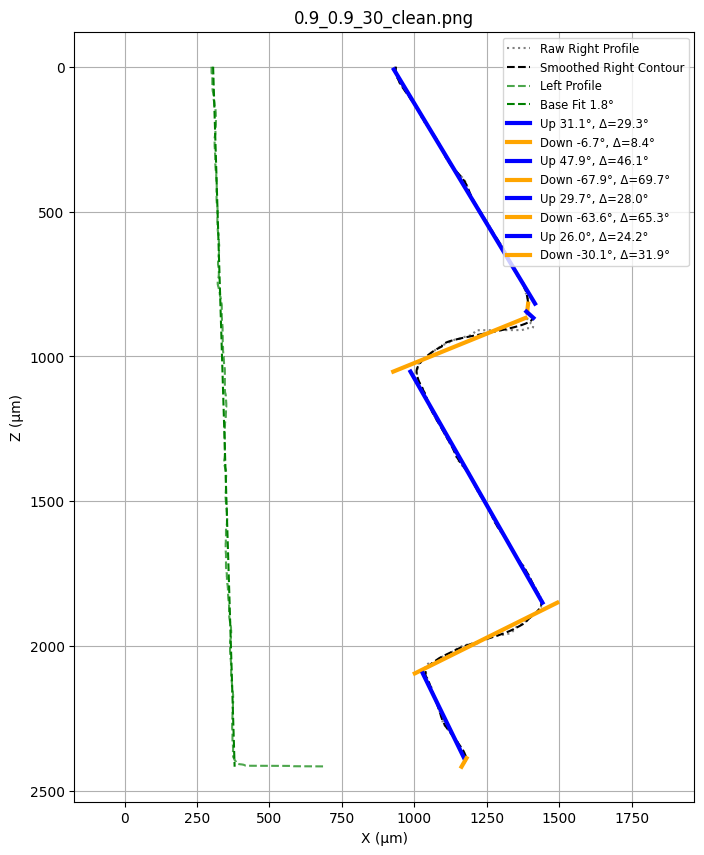

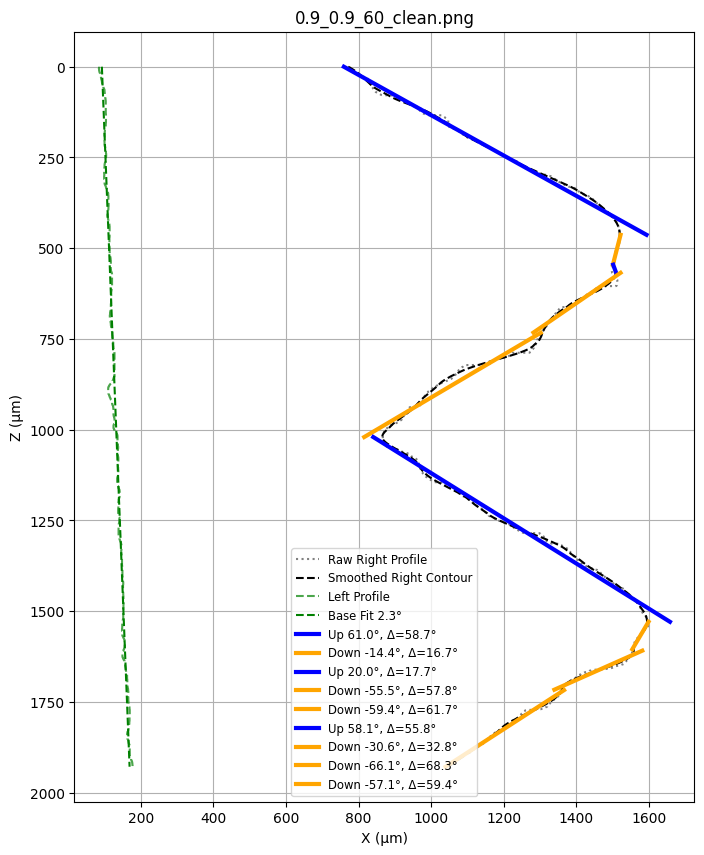

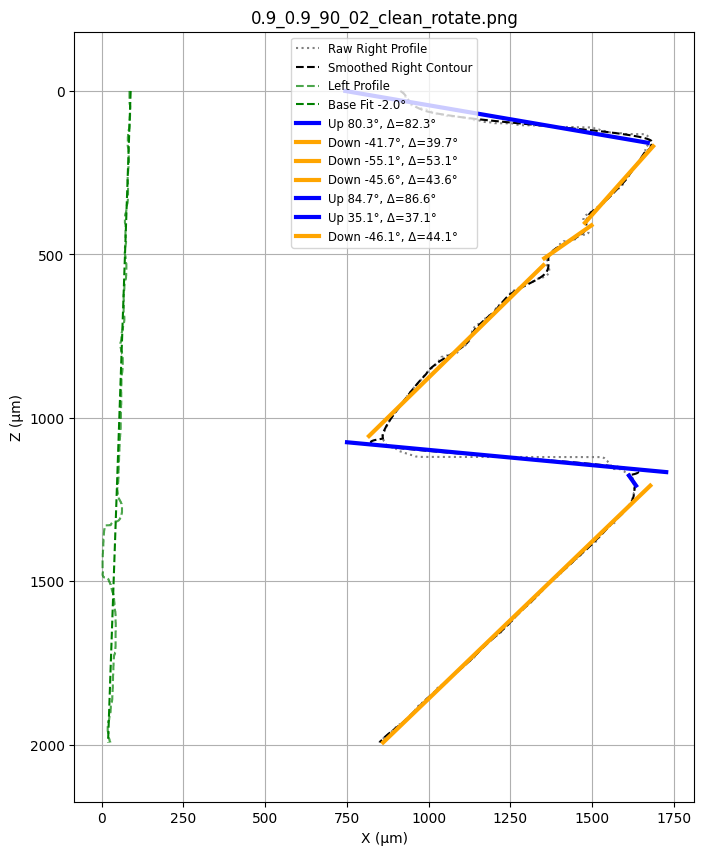

In [180]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import atan2, degrees
from sklearn.linear_model import LinearRegression
import os
from scipy.signal import savgol_filter



def analyze_feature_slopes_auto(
    image_path,
    px_size=0.56,
    z_scale=0.56,
    min_segment_points=30,
    smoothing_ratio=0.07,
):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"❌ 無法讀取影像 {image_path}")
        return

    # === Otsu 二值化 ===
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # === 找最大輪廓 ===
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        print("❌ 無法偵測輪廓")
        return
    main_contour = max(contours, key=cv2.contourArea)

    # === 建立 mask 並補洞去雜訊 ===
    mask = np.zeros_like(binary)
    cv2.drawContours(mask, [main_contour], -1, color=255, thickness=-1)
    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    # === 擷取左右輪廓 ===
    profile_left_px, profile_right_px, valid_z_indices = [], [], []
    for y in range(mask.shape[0]):
        cols = np.where(mask[y] == 255)[0]
        if len(cols) > 0:
            profile_left_px.append(cols[0])
            profile_right_px.append(cols[-1])
            valid_z_indices.append(y)

    if not valid_z_indices:
        print("❌ 無效輪廓")
        return

    # === 座標轉換 ===
    z_vals = np.array(valid_z_indices) * z_scale
    x_vals_left = np.array(profile_left_px) * px_size
    x_vals_right_raw = np.array(profile_right_px) * px_size

    # === 平滑右側 ===
    raw_len = len(x_vals_right_raw)
    window_length = int(raw_len * smoothing_ratio)
    if window_length % 2 == 0:
        window_length += 1
    window_length = max(11, min(window_length, 201))
    x_vals_right_smoothed = savgol_filter(x_vals_right_raw, window_length, polyorder=3)

    # === 基底擬合（左邊） ===
    reg_base = LinearRegression().fit(z_vals.reshape(-1, 1), x_vals_left.reshape(-1, 1))
    slope_base = reg_base.coef_[0][0]
    angle_base = degrees(atan2(slope_base, 1))

    # === 用斜率變化來分段（Up/Down）===
    dx = np.gradient(x_vals_right_smoothed)
    sign = np.sign(dx)

    change_points = [0]
    for i in range(1, len(sign)):
        if sign[i] != sign[i - 1]:
            change_points.append(i)
    change_points.append(len(sign) - 1)

    # === 擬合每段 ===
    fitted_segments = []
    for i in range(len(change_points) - 1):
        idx1 = change_points[i]
        idx2 = change_points[i + 1]
        if idx2 - idx1 < min_segment_points:
            continue

        z_seg = z_vals[idx1 : idx2 + 1]
        x_seg = x_vals_right_smoothed[idx1 : idx2 + 1]
        reg = LinearRegression().fit(z_seg.reshape(-1, 1), x_seg.reshape(-1, 1))
        slope = reg.coef_[0][0]
        angle = degrees(atan2(slope, 1))
        delta = abs(angle - angle_base)
        label = "Up" if slope > 0 else "Down"
        fitted_segments.append((idx1, idx2, angle, label, delta))

    # === 繪圖 ===
    plt.figure(figsize=(8, 10))
    plt.plot(x_vals_right_raw, z_vals, ":", color="gray", label="Raw Right Profile")
    plt.plot(
        x_vals_right_smoothed,
        z_vals,
        "--",
        color="black",
        label="Smoothed Right Contour",
        linewidth=1.5,
    )
    plt.plot(x_vals_left, z_vals, "g--", label="Left Profile", alpha=0.7)
    x_fit_base = reg_base.predict(z_vals.reshape(-1, 1))
    plt.plot(x_fit_base, z_vals, "g--", label=f"Base Fit {angle_base:.1f}°")

    for idx1, idx2, angle, label, delta in fitted_segments:
        z_endpoints = z_vals[[idx1, idx2]]
        model = LinearRegression().fit(
            z_vals[idx1 : idx2 + 1].reshape(-1, 1),
            x_vals_right_smoothed[idx1 : idx2 + 1].reshape(-1, 1),
        )
        x_pred = model.predict(z_endpoints.reshape(-1, 1))
        color = "blue" if label == "Up" else "orange"
        plt.plot(
            x_pred,
            z_endpoints,
            linewidth=3,
            color=color,
            label=f"{label} {angle:.1f}°, Δ={delta:.1f}°",
        )

    plt.xlabel("X (μm)")
    plt.ylabel("Z (μm)")
    plt.legend(fontsize="small")
    plt.grid(True)
    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.title(os.path.basename(image_path))
    plt.show()


image_folder = r"C:\Users\cchih\Desktop\NTHU\MasterThesis\research_log\202508\0801\RemoveBackground"
for file in os.listdir(image_folder):
    if file.endswith(".png"):
        image_path = os.path.join(image_folder, file)
        analyze_feature_slopes_auto(image_path)

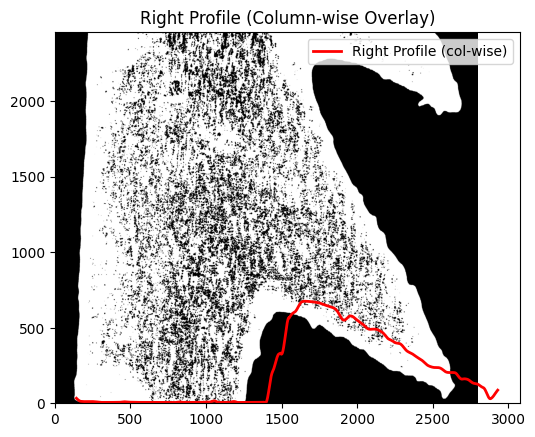

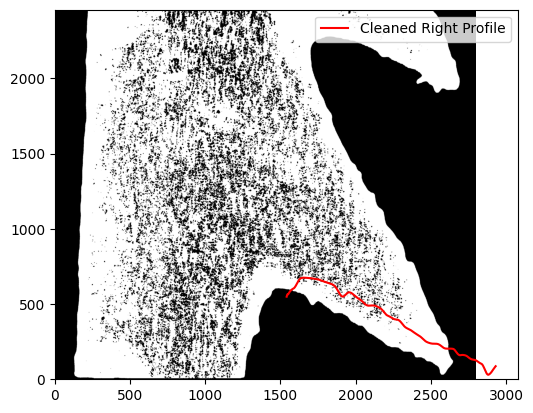

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter


def clean_profile(profile_x, profile_z, smooth_window=51):
    # Step 1: 平滑處理 (optional，可視需求調整)
    if len(profile_z) >= smooth_window:
        profile_z = savgol_filter(profile_z, window_length=smooth_window, polyorder=2)

    # Step 2: 找出主要輪廓段（排除突變跳躍段）
    dx = np.diff(profile_x)
    dz = np.diff(profile_z)
    d = np.sqrt(dx**2 + dz**2)
    threshold = np.percentile(d, 95) * 2  # 允許的跳躍程度

    # 取得連續段 index
    keep_indices = [0]
    for i in range(1, len(d)):
        if d[i - 1] < threshold:
            keep_indices.append(i)
        else:
            break  # 可改成找最大連續段

    return profile_x[keep_indices], profile_z[keep_indices]


def extract_and_clean_right_profile_columnwise(binary_img, px_size=1.12):
    H, W = binary_img.shape
    x_raw, z_raw = [], []

    for x in range(W):
        rows = np.where(binary_img[:, x] == 255)[0]
        if len(rows) > 0:
            y_top = rows[0]
            x_raw.append(x * px_size)
            z_raw.append(y_top * px_size)

    return clean_profile(np.array(x_raw), np.array(z_raw))


def overlay_profile_columnwise(image_path, px_size=1.12):
    # 載入圖像與二值化
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    binary_inv = cv2.bitwise_not(binary)

    # 擷取右側輪廓
    right_x, right_z = extract_and_clean_right_profile_columnwise(binary_inv, px_size)

    # 顯示圖像與疊圖
    plt.figure(figsize=(6, 6))
    plt.imshow(binary_inv, cmap="gray")
    plt.plot(
        right_x, right_z, color="red", linewidth=2, label="Right Profile (col-wise)"
    )
    plt.gca().invert_yaxis()
    plt.title("Right Profile (Column-wise Overlay)")
    plt.legend()
    plt.show()

    # Step 1: 從 column-wise binary mask 擷取右側 profile
    x_raw, z_raw = extract_and_clean_right_profile_columnwise(binary_inv, px_size=1.12)

    # Step 2: 過濾只保留最大連續段
    x_clean, z_clean = clean_profile_keep_largest_continuous_segment(x_raw, z_raw)

    # Step 3: 畫圖確認
    plt.imshow(binary_inv, cmap="gray")
    plt.plot(x_clean, z_clean, "r-", label="Cleaned Right Profile")
    plt.legend()
    plt.gca().invert_yaxis()
    plt.show()


def clean_profile_keep_largest_continuous_segment(x, z, jump_thresh_factor=2.0):
    dx = np.diff(x)
    dz = np.diff(z)
    d = np.sqrt(dx**2 + dz**2)
    threshold = np.percentile(d, 95) * jump_thresh_factor

    segments = []
    start = 0
    for i in range(len(d)):
        if d[i] > threshold:
            segments.append((start, i))
            start = i + 1
    segments.append((start, len(x) - 1))

    # 找最長 segment
    max_len = 0
    best_seg = (0, len(x) - 1)
    for seg in segments:
        if seg[1] - seg[0] > max_len:
            max_len = seg[1] - seg[0]
            best_seg = seg

    i1, i2 = best_seg
    return x[i1 : i2 + 1], z[i1 : i2 + 1]


overlay_profile_columnwise(
    r"C:\Users\cchih\Desktop\NTHU\MasterThesis\research_log\202508\0801\RemoveBackground\0.9_0.9_120.png"
)

## 以斜率變化偵測轉折點


📂 處理檔案: 0.9_0.9_120.png
找到了 65 個輪廓角點。


C:\Users\cchih\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27573 (\N{CJK UNIFIED IDEOGRAPH-6BB5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\cchih\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25214 (\N{CJK UNIFIED IDEOGRAPH-627E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\cchih\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21040 (\N{CJK UNIFIED IDEOGRAPH-5230}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\cchih\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35282 (\N{CJK UNIFIED IDEOGRAPH-89D2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\cchih\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py

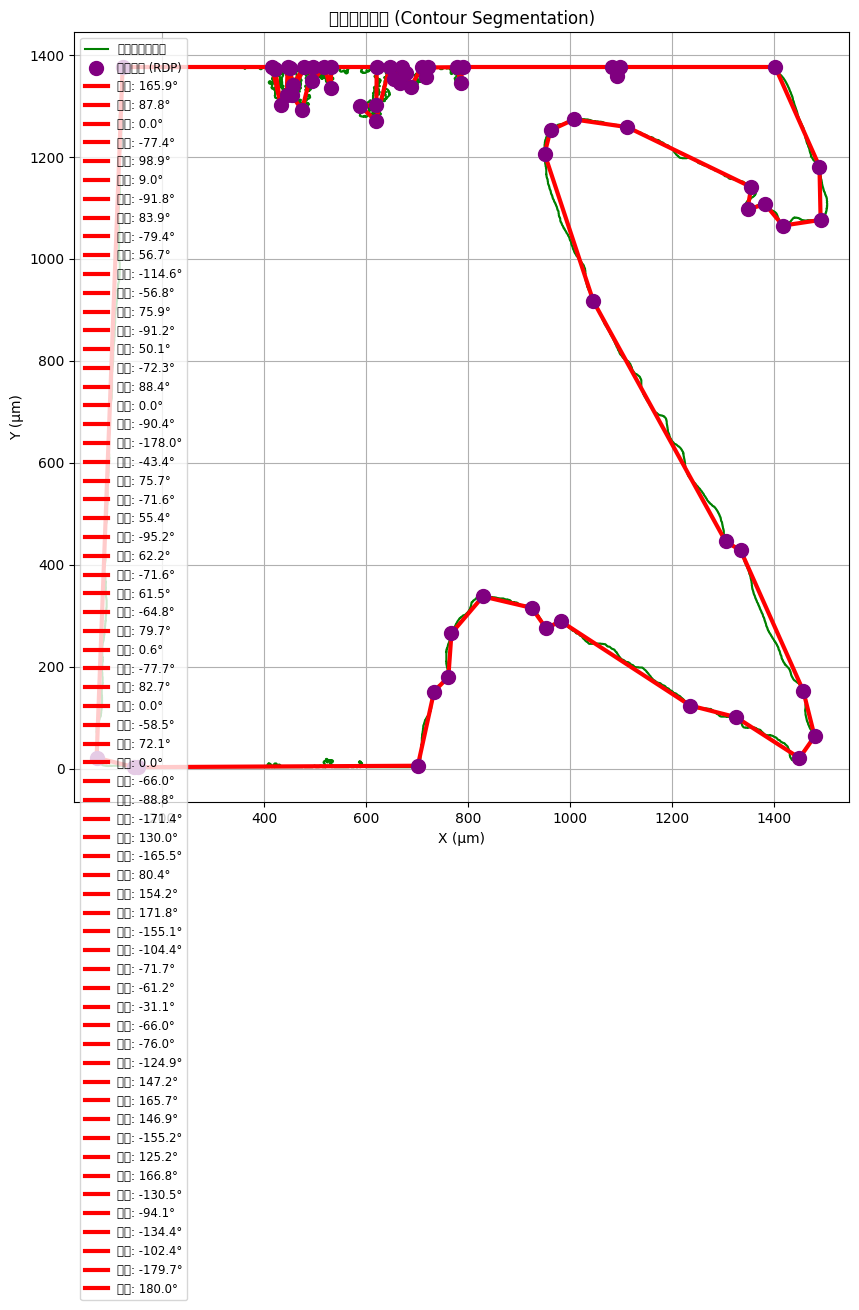

In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor
from math import atan2, degrees

# 由於輪廓點是無序的，我們需要一個穩健的方法來找到角點
from skimage.measure import approximate_polygon


def analyze_contour_segments(image_path, px_size=0.56, rdp_tolerance=5.0):
    """
    最終方案 V2：使用 findContours 獲取單一連續輪廓，
    再使用 RDP 尋找角點並分段擬合。
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"❌ 錯誤：無法讀取影像路徑 {image_path}")
        return

    # 1. 影像二值化
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 2. 尋找輪廓
    # RETR_EXTERNAL: 只找最外層的輪廓
    # CHAIN_APPROX_SIMPLE: 壓縮輪廓點，只保留端點
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        print("❌ 找不到任何輪廓")
        return

    # 3. 選擇最長的輪廓
    main_contour = max(contours, key=cv2.contourArea)

    # 將輪廓點轉換為 (N, 2) 的 numpy 陣列
    # 注意：main_contour 的形狀是 (N, 1, 2)，需要 reshape
    contour_points = main_contour.reshape(-1, 2).astype(np.float32)
    contour_points *= px_size  # 轉換為 μm

    # 4. 使用 RDP 演算法尋找角點
    # coords 需要是 (N, 2) 的 (row, col) 或 (y, x) 格式
    # 我們的 contour_points 是 (x, y) 格式，所以傳入 (y, x)
    coords_for_rdp = contour_points[:, ::-1]  # 從 (x,y) 轉為 (y,x)
    approx_coords = approximate_polygon(coords_for_rdp, tolerance=rdp_tolerance)

    # 將 RDP 返回的角點 (y,x) 轉回 (x,y)
    corner_points = approx_coords[:, ::-1]

    print(f"\n📂 處理檔案: {os.path.basename(image_path)}")
    print(f"找到了 {len(corner_points)} 個輪廓角點。")

    # --- 視覺化 ---
    plt.figure(figsize=(10, 10))
    # 繪製原始的完整輪廓
    plt.plot(contour_points[:, 0], contour_points[:, 1], "g-", label="找到的完整輪廓")
    # 標示 RDP 找到的角點
    plt.scatter(
        corner_points[:, 0],
        corner_points[:, 1],
        c="purple",
        s=100,
        zorder=5,
        label="輪廓角點 (RDP)",
    )

    # 5. 分段擬合與繪圖
    for i in range(len(corner_points)):
        p1 = corner_points[i]
        p2 = corner_points[
            (i + 1) % len(corner_points)
        ]  # 循環，使最後一個點能連回第一個點

        # 計算斜率和角度
        dx = p2[0] - p1[0]
        dy = p2[1] - p1[1]

        if np.abs(dx) < 1e-6:  # 垂直線
            angle_vs_horizontal = 90 if dy > 0 else -90
        else:
            angle_vs_horizontal = degrees(atan2(dy, dx))

        # 繪製擬合線段
        plt.plot(
            [p1[0], p2[0]],
            [p1[1], p2[1]],
            "r-",
            linewidth=3,
            label=f"角度: {angle_vs_horizontal:.1f}°",
        )

    plt.xlabel("X (μm)")
    plt.ylabel("Y (μm)")
    plt.legend(fontsize="small", loc="best")
    plt.grid(True)
    # Y 軸不再需要反轉，因為我們是基於真實座標
    # plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.title("輪廓分段分析 (Contour Segmentation)")
    plt.show()


# --- 主程式執行部分 ---
try:
    # 這裡我們使用您最新上傳的手動標記圖片，但實際分析時應使用原始灰階圖或二值圖
    # 為了方便，我們直接使用 http://googleusercontent.com/file_content/0 這個路徑
    image_path = r"C:\Users\cchih\Desktop\NTHU\MasterThesis\research_log\202508\0801\RemoveBackground\0.9_0.9_120.png"  # 這是您最初的灰階影像

    # 調整 rdp_tolerance 可以控制角的數量，值越大，角越少
    analyze_contour_segments(image_path, rdp_tolerance=15.0)
except Exception as e:
    print(f"發生錯誤: {e}")





📂 處理檔案: 0.9_0.9_120_flip.png
找到了 58 個輪廓角點。


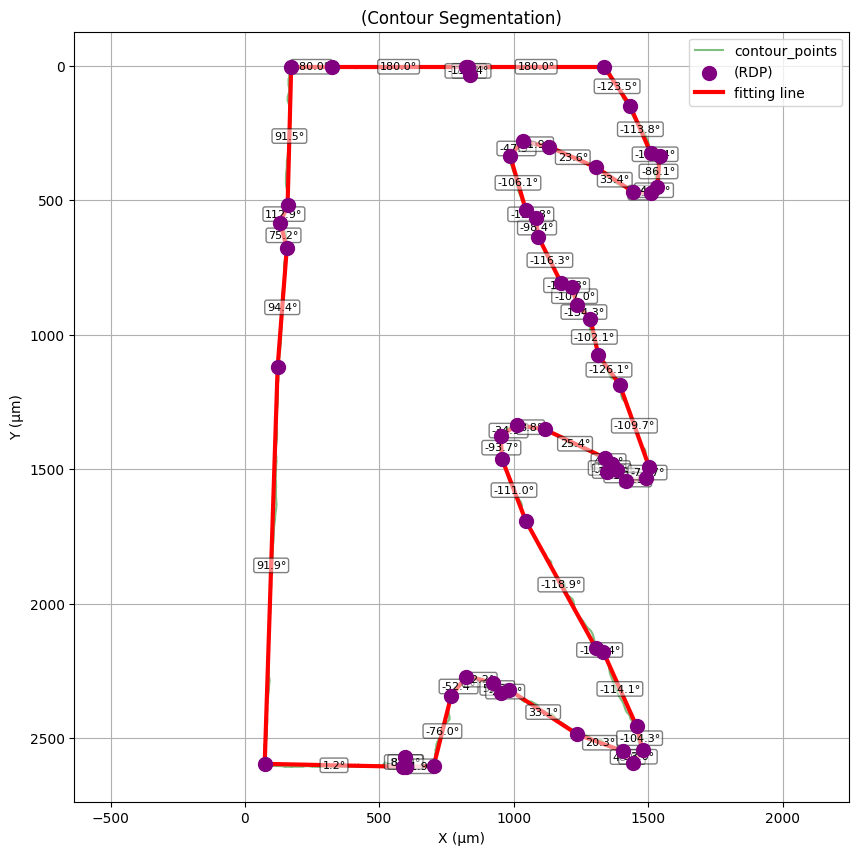

In [179]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import atan2, degrees
from skimage.measure import approximate_polygon


def analyze_contour_segments(image_path, px_size=0.56, rdp_tolerance=15.0):
    """
    最終方案 V3：修正了 Y 軸顛倒問題，並美化了圖例和角度標示。
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"❌ 錯誤：無法讀取影像路徑 {image_path}")
        return

    # 1. 影像二值化
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 2. 尋找輪廓
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        print("❌ 找不到任何輪廓")
        return

    # 3. 選擇最長的輪廓
    main_contour = max(contours, key=cv2.contourArea)
    contour_points = main_contour.reshape(-1, 2).astype(np.float32)
    contour_points *= px_size  # 轉換為 μm

    # 4. 使用 RDP 演算法尋找角點
    coords_for_rdp = contour_points[:, ::-1]  # 從 (x,y) 轉為 (y,x)
    approx_coords = approximate_polygon(coords_for_rdp, tolerance=rdp_tolerance)
    corner_points = approx_coords[:, ::-1]  # 轉回 (x,y)

    print(f"\n📂 處理檔案: {os.path.basename(image_path)}")
    print(f"找到了 {len(corner_points)} 個輪廓角點。")

    # --- 視覺化 ---
    plt.figure(figsize=(10, 10))
    # 繪製原始的完整輪廓
    plt.plot(
        contour_points[:, 0],
        contour_points[:, 1],
        "g-",
        alpha=0.5,
        label="contour_points",
    )
    # 標示 RDP 找到的角點
    plt.scatter(
        corner_points[:, 0],
        corner_points[:, 1],
        c="purple",
        s=100,
        zorder=5,
        label="(RDP)",
    )

    # 5. 分段擬合與繪圖
    for i in range(len(corner_points)):
        p1 = corner_points[i]
        p2 = corner_points[(i + 1) % len(corner_points)]  # 循環

        dx = p2[0] - p1[0]
        dy = p2[1] - p1[1]

        if np.abs(dx) < 1e-6:
            angle_vs_horizontal = 90 if dy > 0 else -90
        else:
            angle_vs_horizontal = degrees(atan2(dy, dx))

        # --- 修正圖例 ---
        # 只在第一次迴圈時加入標籤，之後的線段就不再加入，以保持圖例乾淨
        label = "fitting line" if i == 0 else None
        plt.plot([p1[0], p2[0]], [p1[1], p2[1]], "r-", linewidth=3, label=label)

        # --- 新增：在線段中點標示角度 ---
        mid_point_x = (p1[0] + p2[0]) / 2
        mid_point_y = (p1[1] + p2[1]) / 2
        plt.text(
            mid_point_x,
            mid_point_y,
            f"{angle_vs_horizontal:.1f}°",
            color="black",
            fontsize=8,
            ha="center",
            va="center",
            bbox=dict(facecolor="white", alpha=0.5, boxstyle="round,pad=0.2"),
        )

    plt.xlabel("X (μm)")
    plt.ylabel("Y (μm)")
    plt.legend()
    plt.grid(True)

    # --- 修正座標軸 ---
    # 加回這一行來反轉Y軸，使其符合影像座標系
    plt.gca().invert_yaxis()

    plt.axis("equal")
    plt.title("(Contour Segmentation)")
    plt.show()


# --- 主程式執行部分 ---
try:
    # 這裡我們使用您最新上傳的手動標記圖片，但實際分析時應使用原始灰階圖或二值圖
    # 為了方便，我們直接使用 http://googleusercontent.com/file_content/0 這個路徑
    image_path = r"C:\Users\cchih\Desktop\NTHU\MasterThesis\research_log\202508\0801\RemoveBackground\0.9_0.9_120_flip.png"
    #r"C:\Users\cchih\Desktop\NTHU\MasterThesis\research_log\202508\0801\RemoveBackground\0.9_0.9_120.png"
    
    # r"C:\Users\cchih\Desktop\NTHU\MasterThesis\research_log\202508\0801\RemoveBackground\0.9_0.9_60_clean.png"
    # r"C:\Users\cchih\Desktop\NTHU\MasterThesis\research_log\202508\0801\RemoveBackground\0.9_0.9_30_clean.png"
    # r"C:\Users\cchih\Desktop\NTHU\MasterThesis\research_log\202508\0801\RemoveBackground\0.9_0.9_120.png"

    # 調整 rdp_tolerance 可以控制角的數量，值越大，角越少
    analyze_contour_segments(image_path, rdp_tolerance=15.0)
except Exception as e:
    print(f"發生錯誤: {e}")


📂 處理檔案: 0.9_0.9_30_clean.png
RDP 容差 = 2.0, 找到了 260 個輪廓角點。


C:\Users\cchih\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36650 (\N{CJK UNIFIED IDEOGRAPH-8F2A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\cchih\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24275 (\N{CJK UNIFIED IDEOGRAPH-5ED3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\cchih\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\cchih\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27573 (\N{CJK UNIFIED IDEOGRAPH-6BB5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\cchih\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py

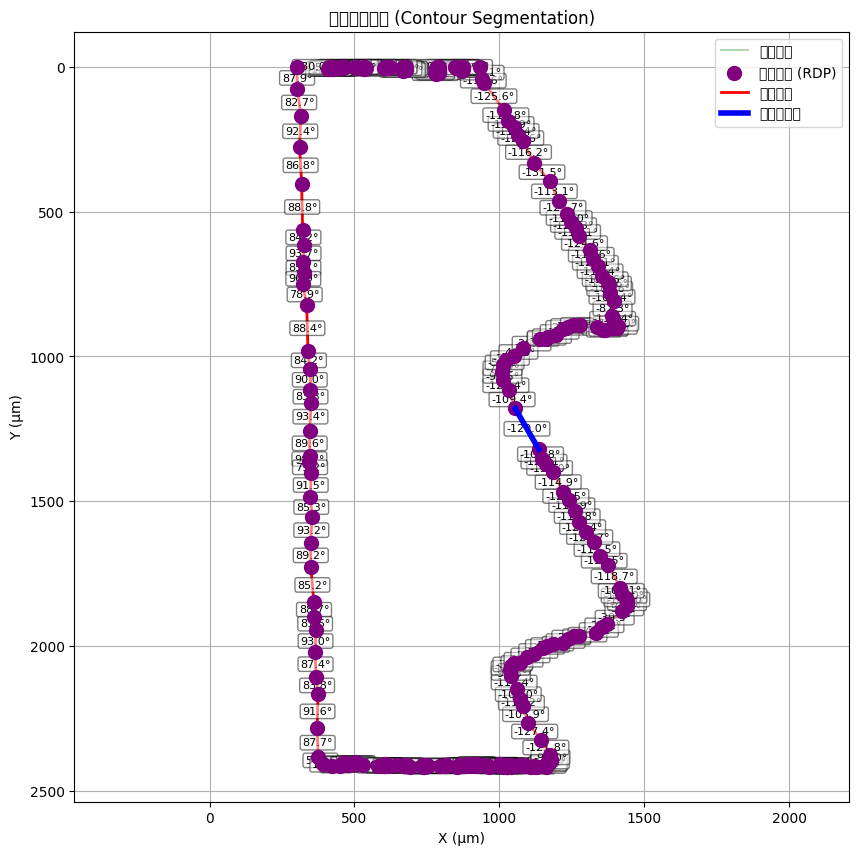


--- 分析結果 ---
最長主斜邊的角度: -120.01°
最長主斜邊的長度: 162.33 μm


In [205]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import atan2, degrees, sqrt
from skimage.measure import approximate_polygon


def analyze_contour_segments(image_path, px_size=0.56, rdp_tolerance=40.0):
    """
    最終方案 V4：優化圖例與標示，並自動找出最長的主斜邊。
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"❌ 錯誤：無法讀取影像路徑 {image_path}")
        return

    # 1. 影像二值化
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 2. 尋找輪廓
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        print("❌ 找不到任何輪廓")
        return

    # 3. 選擇最長的輪廓
    main_contour = max(contours, key=cv2.contourArea)
    contour_points = main_contour.reshape(-1, 2).astype(np.float32)
    contour_points *= px_size  # 轉換為 μm

    # 4. 使用 RDP 演算法尋找角點
    coords_for_rdp = contour_points[:, ::-1]  # 從 (x,y) 轉為 (y,x)
    approx_coords = approximate_polygon(coords_for_rdp, tolerance=rdp_tolerance)
    corner_points = approx_coords[:, ::-1]  # 轉回 (x,y)

    print(f"\n📂 處理檔案: {os.path.basename(image_path)}")
    print(f"RDP 容差 = {rdp_tolerance}, 找到了 {len(corner_points)} 個輪廓角點。")

    # --- 視覺化 ---
    plt.figure(figsize=(10, 10))
    plt.plot(
        contour_points[:, 0], contour_points[:, 1], "g-", alpha=0.3, label="完整輪廓"
    )
    plt.scatter(
        corner_points[:, 0],
        corner_points[:, 1],
        c="purple",
        s=100,
        zorder=5,
        label="輪廓角點 (RDP)",
    )

    # 5. 分段擬合與分析
    longest_segment_info = {"length": 0, "angle": 0, "p1": None, "p2": None}

    for i in range(len(corner_points)):
        p1 = corner_points[i]
        p2 = corner_points[(i + 1) % len(corner_points)]  # 循環

        dx = p2[0] - p1[0]
        dy = p2[1] - p1[1]

        # 計算線段長度
        length = sqrt(dx**2 + dy**2)

        if np.abs(dx) < 1e-6:
            angle_vs_horizontal = 90 if dy > 0 else -90
        else:
            angle_vs_horizontal = degrees(atan2(dy, dx))

        # 繪製線段
        label = "擬合線段" if i == 0 else None
        plt.plot([p1[0], p2[0]], [p1[1], p2[1]], "r-", linewidth=2, label=label)

        # 標示角度
        mid_point_x = (p1[0] + p2[0]) / 2
        mid_point_y = (p1[1] + p2[1]) / 2
        plt.text(
            mid_point_x,
            mid_point_y,
            f"{angle_vs_horizontal:.1f}°",
            color="black",
            fontsize=8,
            ha="center",
            va="center",
            bbox=dict(facecolor="white", alpha=0.5, boxstyle="round,pad=0.2"),
        )

        # 追蹤最長的線段
        if length > longest_segment_info["length"]:
            longest_segment_info["length"] = length
            longest_segment_info["angle"] = angle_vs_horizontal
            longest_segment_info["p1"] = p1
            longest_segment_info["p2"] = p2

    # 強調繪製最長的線段
    if longest_segment_info["p1"] is not None:
        p1 = longest_segment_info["p1"]
        p2 = longest_segment_info["p2"]
        plt.plot(
            [p1[0], p2[0]],
            [p1[1], p2[1]],
            "b-",
            linewidth=4,
            zorder=10,
            label="最長主斜邊",
        )

    plt.xlabel("X (μm)")
    plt.ylabel("Y (μm)")
    plt.legend()
    plt.grid(True)
    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.title("輪廓分段分析 (Contour Segmentation)")
    plt.show()

    # 單獨印出最長邊的資訊
    print("\n--- 分析結果 ---")
    print(f"最長主斜邊的角度: {longest_segment_info['angle']:.2f}°")
    print(f"最長主斜邊的長度: {longest_segment_info['length']:.2f} μm")


# --- 主程式執行部分 ---
try:
    # 使用者上傳的檔案位於 '0.9_0.9_120.jpg'
    image_path = (
        r"\\140.114.141.95\nas\112\112033635_CHI\GA\0728OM\0.9_0.9\0.9_0.9_30_clean.png"
    )

    # 解決方案：將 rdp_tolerance 從 15.0 大幅提高
    # 您可以從 40.0 開始嘗試，如果分段還是太多，可以繼續增加到 50, 60, ...
    analyze_contour_segments(image_path, rdp_tolerance=2.0)
except FileNotFoundError:
    print(f"找不到檔案，請確認檔案路徑是否正確。")
except Exception as e:
    print(f"發生錯誤: {e}")


Processing file: 0.9_0.9_120.png
RDP Tolerance = 10.0, Found 86 corner points.

Substrate defined by the longest segment (index 2):
  - Substrate Angle: 87.06° (relative to horizontal)
  - Substrate Length: 894.38 μm


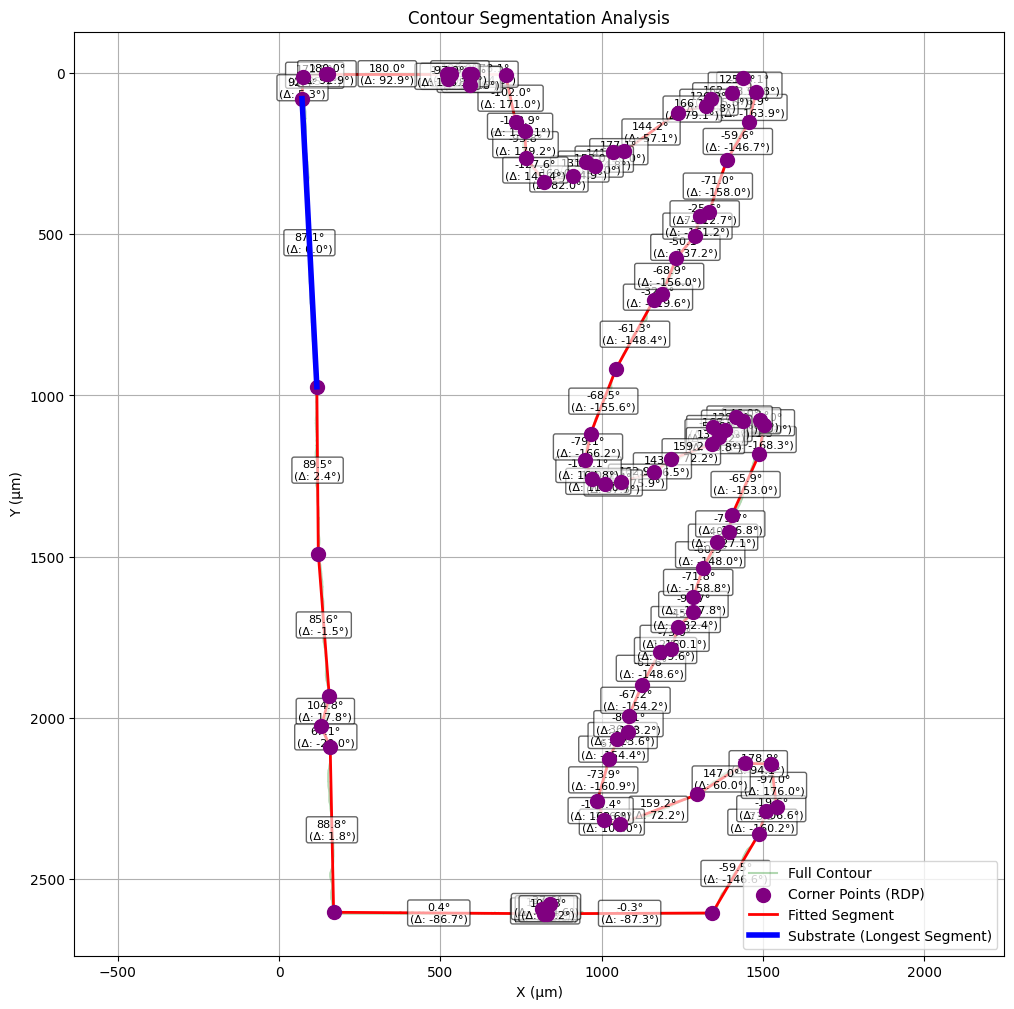

In [204]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import atan2, degrees, sqrt
from skimage.measure import approximate_polygon


def analyze_contour_segments(image_path, px_size=0.56, rdp_tolerance=40.0):
    """
    Final Version: English plot with relative angle calculation against the longest segment (substrate).
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Error: Could not read the image at {image_path}")
        return

    # 1. Binarize Image
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 2. Find Contours
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        print("Error: No contours found.")
        return

    # 3. Select the longest contour
    main_contour = max(contours, key=cv2.contourArea)
    contour_points = main_contour.reshape(-1, 2).astype(np.float32)
    contour_points *= px_size  # Convert to μm

    # 4. Find corner points using RDP
    coords_for_rdp = contour_points[:, ::-1]  # Convert from (x,y) to (y,x)
    approx_coords = approximate_polygon(coords_for_rdp, tolerance=rdp_tolerance)
    corner_points = approx_coords[:, ::-1]  # Convert back to (x,y)

    print(f"\nProcessing file: {os.path.basename(image_path)}")
    print(f"RDP Tolerance = {rdp_tolerance}, Found {len(corner_points)} corner points.")

    # 5. First pass: Calculate all segments and find the longest one (the substrate)
    segments = []
    longest_segment_info = {"length": 0, "angle": 0, "index": -1}
    for i in range(len(corner_points)):
        p1 = corner_points[i]
        p2 = corner_points[(i + 1) % len(corner_points)]  # Loop back to start

        dx = p2[0] - p1[0]
        dy = p2[1] - p1[1]
        length = sqrt(dx**2 + dy**2)

        if np.abs(dx) < 1e-6:
            angle = 90 if dy > 0 else -90
        else:
            angle = degrees(atan2(dy, dx))

        segments.append({"p1": p1, "p2": p2, "length": length, "angle": angle})

        if length > longest_segment_info["length"]:
            longest_segment_info = {"length": length, "angle": angle, "index": i}

    substrate_angle = longest_segment_info["angle"]
    print(
        f"\nSubstrate defined by the longest segment (index {longest_segment_info['index']}):"
    )
    print(f"  - Substrate Angle: {substrate_angle:.2f}° (relative to horizontal)")
    print(f"  - Substrate Length: {longest_segment_info['length']:.2f} μm")

    # --- Visualization ---
    plt.figure(figsize=(12, 12))
    plt.plot(
        contour_points[:, 0],
        contour_points[:, 1],
        "g-",
        alpha=0.3,
        label="Full Contour",
    )
    plt.scatter(
        corner_points[:, 0],
        corner_points[:, 1],
        c="purple",
        s=100,
        zorder=5,
        label="Corner Points (RDP)",
    )

    # 6. Second pass: Plotting with relative angles
    for i, seg in enumerate(segments):
        p1, p2 = seg["p1"], seg["p2"]
        angle = seg["angle"]

        # Calculate the angle relative to the substrate
        relative_angle = angle - substrate_angle
        # Normalize to [-180, 180]
        if relative_angle > 180:
            relative_angle -= 360
        if relative_angle <= -180:
            relative_angle += 360

        # Highlight the substrate (longest segment)
        if i == longest_segment_info["index"]:
            plt.plot(
                [p1[0], p2[0]],
                [p1[1], p2[1]],
                "b-",
                linewidth=4,
                zorder=10,
                label="Substrate (Longest Segment)",
            )
        else:
            plt.plot(
                [p1[0], p2[0]],
                [p1[1], p2[1]],
                "r-",
                linewidth=2,
                label="Fitted Segment" if i == 0 else None,
            )

        # Annotate with both absolute and relative angles
        mid_point_x = (p1[0] + p2[0]) / 2
        mid_point_y = (p1[1] + p2[1]) / 2
        annotation_text = f"{angle:.1f}°\n(Δ: {relative_angle:.1f}°)"
        plt.text(
            mid_point_x,
            mid_point_y,
            annotation_text,
            color="black",
            fontsize=8,
            ha="center",
            va="center",
            bbox=dict(facecolor="white", alpha=0.6, boxstyle="round,pad=0.2"),
        )

    plt.xlabel("X (μm)")
    plt.ylabel("Y (μm)")
    plt.legend()
    plt.grid(True)
    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.title("Contour Segmentation Analysis")
    plt.show()


# --- Main execution block ---
try:
    # Use the image provided by the user
    image_path = r"C:\Users\cchih\Desktop\NTHU\MasterThesis\research_log\202508\0801\RemoveBackground\0.9_0.9_120.png"

    # Adjust rdp_tolerance to control the number of corners.
    # Higher value = fewer corners, longer segments.
    analyze_contour_segments(image_path, rdp_tolerance=10.0)
except FileNotFoundError:
    print(f"Error: File not found. Please check the path.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Processing file: 0.9_0.9_60_binary01_crop.png
RDP Tolerance = 5.0, Found 120 corner points.


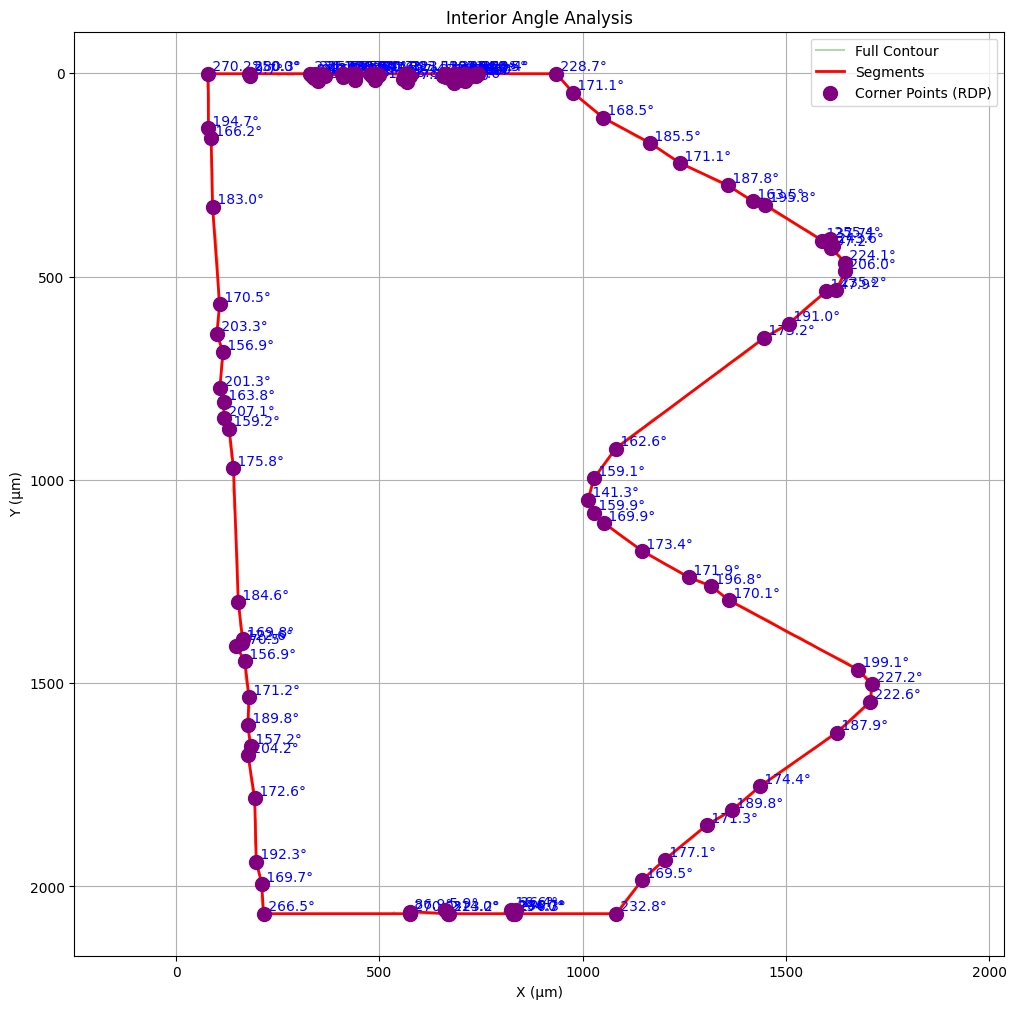

In [190]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import degrees, acos
from skimage.measure import approximate_polygon


def calculate_signed_area(contour):
    """
    使用 Shoelace formula 計算輪廓的帶符號面積，以相容舊版 OpenCV。
    正值表示逆時針(CCW)，負值表示順時針(CW)。
    """
    x = contour[:, 0, 0]
    y = contour[:, 0, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


def analyze_interior_angles(image_path, px_size=0.56, rdp_tolerance=40.0):
    """
    最終方案 V6：修正 OpenCV 版本相容性問題，手動計算帶符號面積。
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Error: Could not read the image at {image_path}")
        return

    # 1. Binarize Image
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 2. Find Contours
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        print("Error: No contours found.")
        return

    # 3. Select the longest contour and check its orientation
    main_contour = max(contours, key=cv2.contourArea)

    # *** 這裡是修正的地方 ***
    # 使用我們自己的函式來取代舊版不支援的 signed=True 參數
    contour_area = calculate_signed_area(main_contour)
    is_ccw = contour_area > 0

    contour_points = main_contour.reshape(-1, 2).astype(np.float32)
    contour_points *= px_size  # Convert to μm

    # 4. Find corner points using RDP
    coords_for_rdp = contour_points[:, ::-1]  # (x,y) -> (y,x)
    approx_coords = approximate_polygon(coords_for_rdp, tolerance=rdp_tolerance)
    corner_points = approx_coords[:, ::-1]  # (y,x) -> (x,y)

    print(f"\nProcessing file: {os.path.basename(image_path)}")
    print(f"RDP Tolerance = {rdp_tolerance}, Found {len(corner_points)} corner points.")

    # --- Visualization ---
    plt.figure(figsize=(12, 12))
    plt.plot(
        contour_points[:, 0],
        contour_points[:, 1],
        "g-",
        alpha=0.3,
        label="Full Contour",
    )

    # 5. Calculate and annotate the interior angle for each corner
    num_corners = len(corner_points)
    for i in range(num_corners):
        p_prev = corner_points[(i - 1 + num_corners) % num_corners]
        p_curr = corner_points[i]
        p_next = corner_points[(i + 1) % num_corners]

        v1 = p_prev - p_curr
        v2 = p_next - p_curr

        dot_product = np.dot(v1, v2)
        norm_v1 = np.linalg.norm(v1)
        norm_v2 = np.linalg.norm(v2)

        cos_angle = dot_product / (norm_v1 * norm_v2)
        angle_rad = acos(np.clip(cos_angle, -1.0, 1.0))
        angle_deg = degrees(angle_rad)

        cross_product_z = v1[0] * v2[1] - v1[1] * v2[0]

        if (is_ccw and cross_product_z < 0) or (not is_ccw and cross_product_z > 0):
            interior_angle = 360 - angle_deg
        else:
            interior_angle = angle_deg

        plt.text(
            p_curr[0],
            p_curr[1],
            f" {interior_angle:.1f}°",
            color="blue",
            fontsize=10,
            ha="left",
            va="bottom",
        )

    # Plot segments and corner points
    plt.plot(
        np.append(corner_points[:, 0], corner_points[0, 0]),
        np.append(corner_points[:, 1], corner_points[0, 1]),
        "r-",
        linewidth=2,
        label="Segments",
    )
    plt.scatter(
        corner_points[:, 0],
        corner_points[:, 1],
        c="purple",
        s=100,
        zorder=5,
        label="Corner Points (RDP)",
    )

    plt.xlabel("X (μm)")
    plt.ylabel("Y (μm)")
    plt.legend()
    plt.grid(True)
    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.title("Interior Angle Analysis")
    plt.show()


# --- Main execution block ---
try:
    # Use the user-provided image
    image_path = (
        r"\\140.114.141.95\nas\112\112033635_CHI\GA\0729OM\0.9_0.9_60_binary01_crop.png"
    )

    # Adjust rdp_tolerance to control the number of corners.
    analyze_interior_angles(image_path, rdp_tolerance=5.0)
except FileNotFoundError:
    print(f"Error: File not found. Please check the path.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

## corner_points


Processing file: 0.9_0.9_120.png
RDP Tolerance = 15.0, Found 52 corner points.


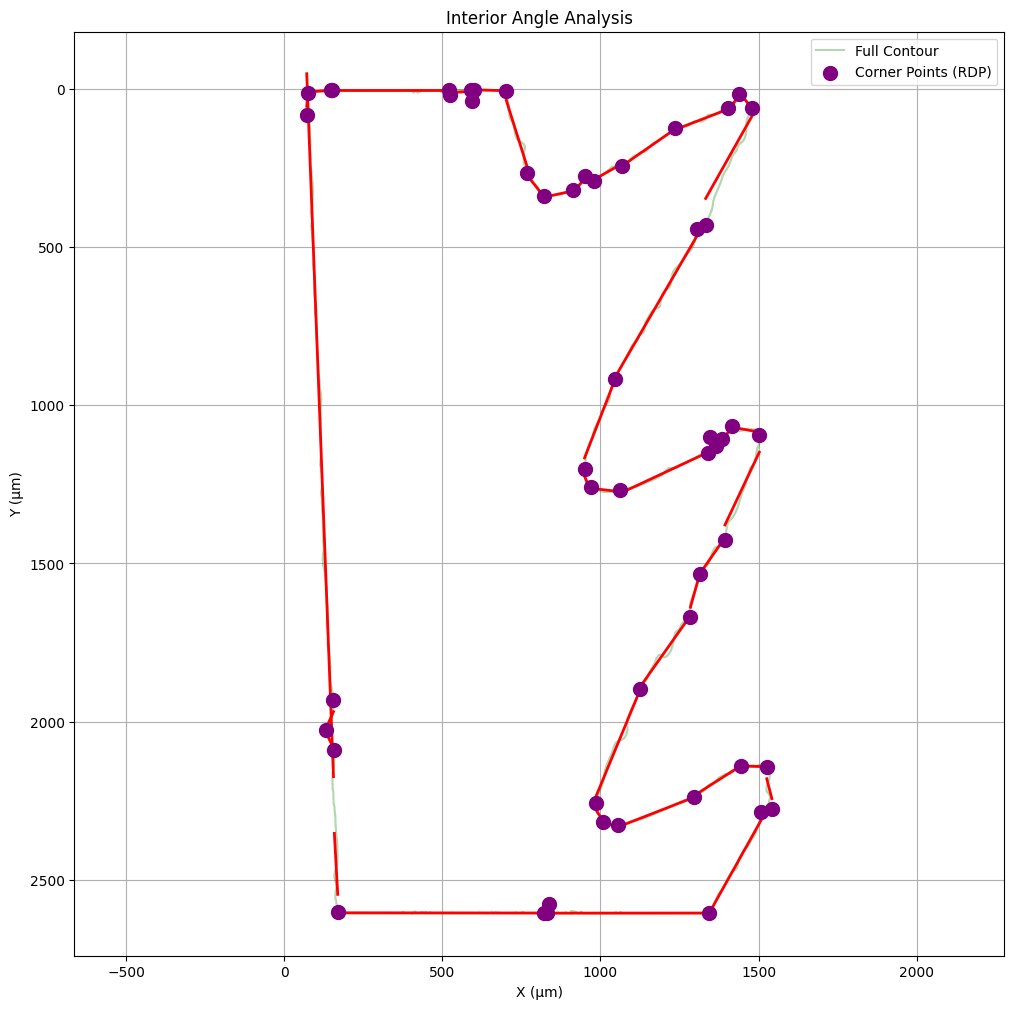

In [200]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import degrees, acos
from skimage.measure import approximate_polygon


def calculate_signed_area(contour):
    """
    使用 Shoelace formula 計算輪廓的帶符號面積，以相容舊版 OpenCV。
    正值表示逆時針(CCW)，負值表示順時針(CW)。
    """
    x = contour[:, 0, 0]
    y = contour[:, 0, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


def analyze_interior_angles(image_path, px_size=0.56, rdp_tolerance=40.0):
    """
    最終方案 V6：修正 OpenCV 版本相容性問題，手動計算帶符號面積。
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Error: Could not read the image at {image_path}")
        return

    # 1. Binarize Image
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 2. Find Contours
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        print("Error: No contours found.")
        return

    # 3. Select the longest contour and check its orientation
    main_contour = max(contours, key=cv2.contourArea)

    # *** 這裡是修正的地方 ***
    # 使用我們自己的函式來取代舊版不支援的 signed=True 參數
    contour_area = calculate_signed_area(main_contour)
    is_ccw = contour_area > 0

    contour_points = main_contour.reshape(-1, 2).astype(np.float32)
    contour_points *= px_size  # Convert to μm

    # 4. Find corner points using RDP
    coords_for_rdp = contour_points[:, ::-1]  # (x,y) -> (y,x)
    approx_coords = approximate_polygon(coords_for_rdp, tolerance=rdp_tolerance)
    corner_points = approx_coords[:, ::-1]  # (y,x) -> (x,y)

    print(f"\nProcessing file: {os.path.basename(image_path)}")
    print(f"RDP Tolerance = {rdp_tolerance}, Found {len(corner_points)} corner points.")

    # --- Visualization ---
    plt.figure(figsize=(12, 12))
    plt.plot(
        contour_points[:, 0],
        contour_points[:, 1],
        "g-",
        alpha=0.3,
        label="Full Contour",
    )

    # 5. Calculate and annotate the interior angle for each corner
    num_corners = len(corner_points)
    from sklearn.linear_model import LinearRegression

    # --- 改為擬合線段而非直接連線 ---
    for i in range(len(corner_points)):
        pt_start = corner_points[i]
        pt_end = corner_points[(i + 1) % len(corner_points)]

        # 找出原始輪廓中介於兩角點之間的點
        x0, y0 = pt_start
        x1, y1 = pt_end

        # 取出在 bounding box 內的點
        min_x, max_x = sorted([x0, x1])
        min_y, max_y = sorted([y0, y1])
        in_segment_mask = (
            (contour_points[:, 0] >= min_x)
            & (contour_points[:, 0] <= max_x)
            & (contour_points[:, 1] >= min_y)
            & (contour_points[:, 1] <= max_y)
        )
        segment_pts = contour_points[in_segment_mask]

        if len(segment_pts) < 2:
            continue  # 跳過點數太少的區段

        # 線性擬合 y = a*x + b
        X = segment_pts[:, 0].reshape(-1, 1)
        Y = segment_pts[:, 1].reshape(-1, 1)
        model = LinearRegression().fit(X, Y)
        x_fit = np.array([x0, x1]).reshape(-1, 1)
        y_fit = model.predict(x_fit)

        plt.plot(x_fit, y_fit, "r-", linewidth=2)

    # Plot segments and corner points
    # plt.plot(
    #     np.append(corner_points[:, 0], corner_points[0, 0]),
    #     np.append(corner_points[:, 1], corner_points[0, 1]),
    #     "r-",
    #     linewidth=2,
    #     label="Segments",
    # )
    plt.scatter(
        corner_points[:, 0],
        corner_points[:, 1],
        c="purple",
        s=100,
        zorder=5,
        label="Corner Points (RDP)",
    )

    plt.xlabel("X (μm)")
    plt.ylabel("Y (μm)")
    plt.legend()
    plt.grid(True)
    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.title("Interior Angle Analysis")
    plt.show()


# --- Main execution block ---
try:
    # Use the user-provided image
    image_path = (
        #r"\\140.114.141.95\nas\112\112033635_CHI\GA\0729OM\0.9_0.9_60_binary01_crop.png"
        r"\\140.114.141.95\nas\112\112033635_CHI\GA\0728OM\0.9_0.9\0.9_0.9_120.png"
    )

    # Adjust rdp_tolerance to control the number of corners.
    analyze_interior_angles(image_path, rdp_tolerance=15.0)
except FileNotFoundError:
    print(f"Error: File not found. Please check the path.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


📂 File: 0.9_0.9_60_binary01_crop.png
📐 RDP Tolerance = 50.0, Found 8 corner points.

🟦 基板 segment：index=0, angle=-176.23°
🔻 左斜邊與基板夾角：0.02°
🔺 右斜邊與基板夾角：0.02°

🟦 基板 segment：index=1, angle=-90.00°
🔻 左斜邊與基板夾角：86.23°
🔺 右斜邊與基板夾角：86.23°

🟦 基板 segment：index=1, angle=-90.00°
🔻 左斜邊與基板夾角：86.23°
🔺 右斜邊與基板夾角：39.89°

🟦 基板 segment：index=1, angle=-90.00°
🔻 左斜邊與基板夾角：86.23°
🔺 右斜邊與基板夾角：39.89°

🟦 基板 segment：index=1, angle=-90.00°
🔻 左斜邊與基板夾角：86.23°
🔺 右斜邊與基板夾角：39.89°

🟦 基板 segment：index=1, angle=-90.00°
🔻 左斜邊與基板夾角：86.23°
🔺 右斜邊與基板夾角：39.89°

🟦 基板 segment：index=1, angle=-90.00°
🔻 左斜邊與基板夾角：86.23°
🔺 右斜邊與基板夾角：39.89°

🟦 基板 segment：index=1, angle=-90.00°
🔻 左斜邊與基板夾角：86.23°
🔺 右斜邊與基板夾角：39.89°


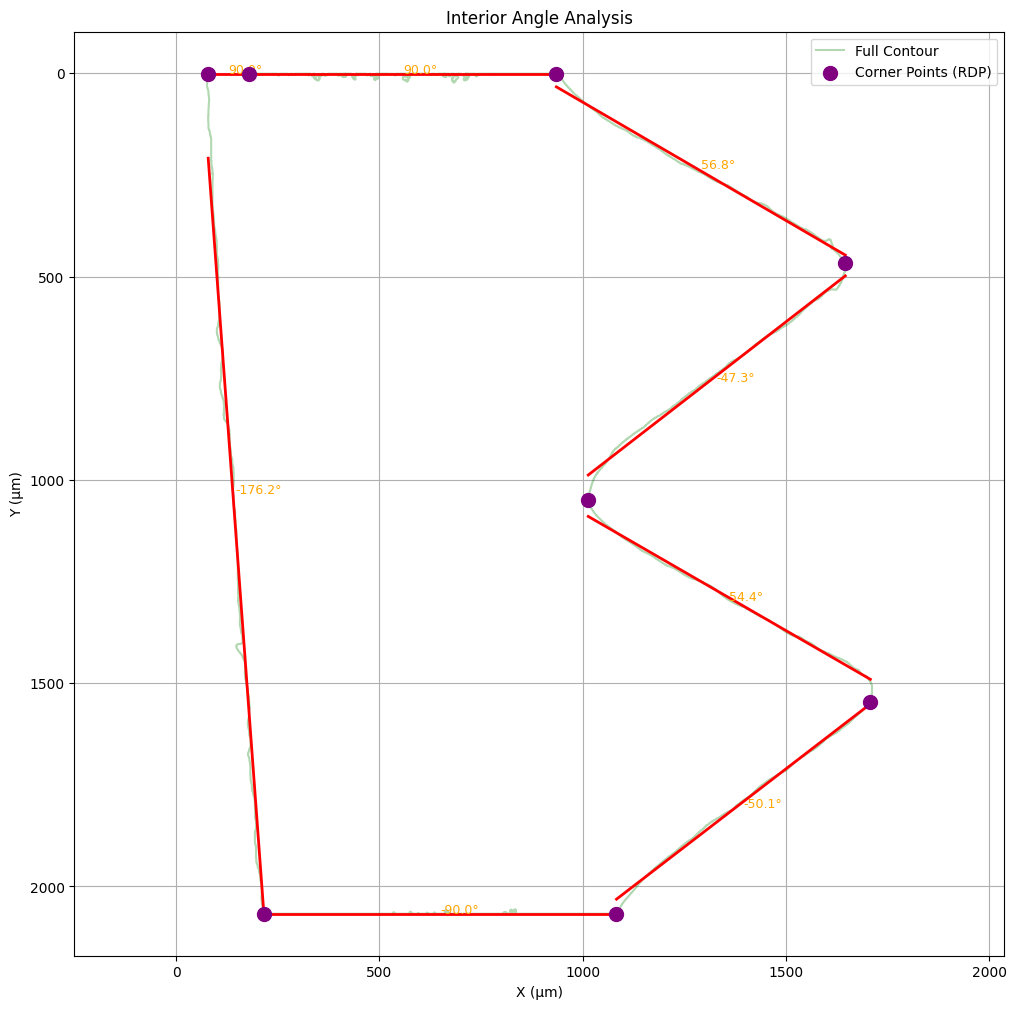

In [234]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import degrees, acos
from skimage.measure import approximate_polygon
from sklearn.linear_model import LinearRegression
import os


def calculate_signed_area(contour):
    x = contour[:, 0, 0]
    y = contour[:, 0, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


def analyze_interior_angles(image_path, px_size=0.56, rdp_tolerance=40.0):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Error: Could not read the image at {image_path}")
        return

    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        print("Error: No contours found.")
        return

    main_contour = max(contours, key=cv2.contourArea)
    contour_area = calculate_signed_area(main_contour)
    is_ccw = contour_area > 0
    contour_points = main_contour.reshape(-1, 2).astype(np.float32)
    contour_points *= px_size  # convert to μm

    coords_for_rdp = contour_points[:, ::-1]
    approx_coords = approximate_polygon(coords_for_rdp, tolerance=rdp_tolerance)
    corner_points = approx_coords[:, ::-1]

    print(f"\n📂 File: {os.path.basename(image_path)}")
    print(
        f"📐 RDP Tolerance = {rdp_tolerance}, Found {len(corner_points)} corner points."
    )

    plt.figure(figsize=(12, 12))
    plt.plot(
        contour_points[:, 0],
        contour_points[:, 1],
        "g-",
        alpha=0.3,
        label="Full Contour",
    )

    # ---------- Segment 擬合 ----------
    segments = []
    angles = []
    for i in range(len(corner_points)):
        pt_start = corner_points[i]
        pt_end = corner_points[(i + 1) % len(corner_points)]

        x0, y0 = pt_start
        x1, y1 = pt_end

        min_x, max_x = sorted([x0, x1])
        min_y, max_y = sorted([y0, y1])
        in_segment_mask = (
            (contour_points[:, 0] >= min_x)
            & (contour_points[:, 0] <= max_x)
            & (contour_points[:, 1] >= min_y)
            & (contour_points[:, 1] <= max_y)
        )
        segment_pts = contour_points[in_segment_mask]
        if len(segment_pts) < 2:
            continue

        X = segment_pts[:, 0].reshape(-1, 1)
        Y = segment_pts[:, 1].reshape(-1, 1)
        model = LinearRegression().fit(X, Y)
        x_fit = np.array([x0, x1]).reshape(-1, 1)
        y_fit = model.predict(x_fit)

        plt.plot(x_fit, y_fit, "r-", linewidth=2)

        # 儲存方向與中點位置
        vec = np.array([y0 - y1,x0 - x1])
        angle_rad = np.arctan2(vec[1], vec[0])
        angle_deg = np.degrees(angle_rad)
        angles.append(angle_deg)
        segments.append((pt_start, pt_end))

        cx, cy = (pt_start + pt_end) / 2
        plt.text(cx, cy, f"{angle_deg:.1f}°", color="orange", fontsize=9)



        # ---------- 找出垂直基板與斜邊 ----------
        # 新邏輯：找最接近 ±90° 的 segment 當作基板
        base_idx = np.argmin([abs(abs(a) - 90) for a in angles])
        base_angle = angles[base_idx]

        left_idx = (base_idx - 1 + len(angles)) % len(angles)
        right_idx = (base_idx + 1) % len(angles)
        # left_angle = angles[left_idx]
        # right_angle = angles[right_idx]

        # left_diff = abs((left_angle - base_angle + 180) % 360 - 180)
        # right_diff = abs((right_angle - base_angle + 180) % 360 - 180)

        # print(f"\n🟦 基板 segment：index={base_idx}, angle={base_angle:.2f}°")
        # print(f"🔻 左斜邊相對基板夾角差：{left_diff:.2f}°")
        # print(f"🔺 右斜邊相對基板夾角差：{right_diff:.2f}°")

        # 取得方向向量

        def unit_vector(p1, p2):
            vec = p2 - p1
            return vec / np.linalg.norm(vec)

        v_base = unit_vector(*segments[base_idx])
        v_left = unit_vector(*segments[left_idx])
        v_right = unit_vector(*segments[right_idx])

        # 計算夾角（radians → degrees）
        def angle_between(v1, v2):
            cos_theta = np.clip(np.dot(v1, v2), -1.0, 1.0)
            return np.degrees(np.arccos(cos_theta))

        angle_left = angle_between(v_base, v_left)
        angle_right = angle_between(v_base, v_right)

        print(f"\n🟦 基板 segment：index={base_idx}, angle={base_angle:.2f}°")
        print(f"🔻 左斜邊與基板夾角：{angle_left:.2f}°")
        print(f"🔺 右斜邊與基板夾角：{angle_right:.2f}°")

    # ---------- 視覺化 ----------
    plt.scatter(
        corner_points[:, 0],
        corner_points[:, 1],
        c="purple",
        s=100,
        zorder=5,
        label="Corner Points (RDP)",
    )
    
    
    plt.xlabel("X (μm)")
    plt.ylabel("Y (μm)")
    plt.legend()
    plt.grid(True)
    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.title("Interior Angle Analysis")
    plt.show()


# --- Main execution block ---
try:
    # Use the user-provided image
    image_path = (
        r"\\140.114.141.95\nas\112\112033635_CHI\GA\0729OM\0.9_0.9_60_binary01_crop.png"
        #r"\\140.114.141.95\nas\112\112033635_CHI\GA\0729OM\0.76_0.9_59_binary02_crop_clean.png"
    )

    # Adjust rdp_tolerance to control the number of corners.
    analyze_interior_angles(image_path, rdp_tolerance=50.0)
except FileNotFoundError:
    print(f"Error: File not found. Please check the path.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


📂 File: 0.9_0.9_60_binary01_crop.png
📐 RDP Tolerance = 30.0, Found 12 corner points.

🟦 基板 segment：index=0, angle=86.23°
🔻 左斜邊與基板夾角：86.23°
🔺 右斜邊與基板夾角：93.77°


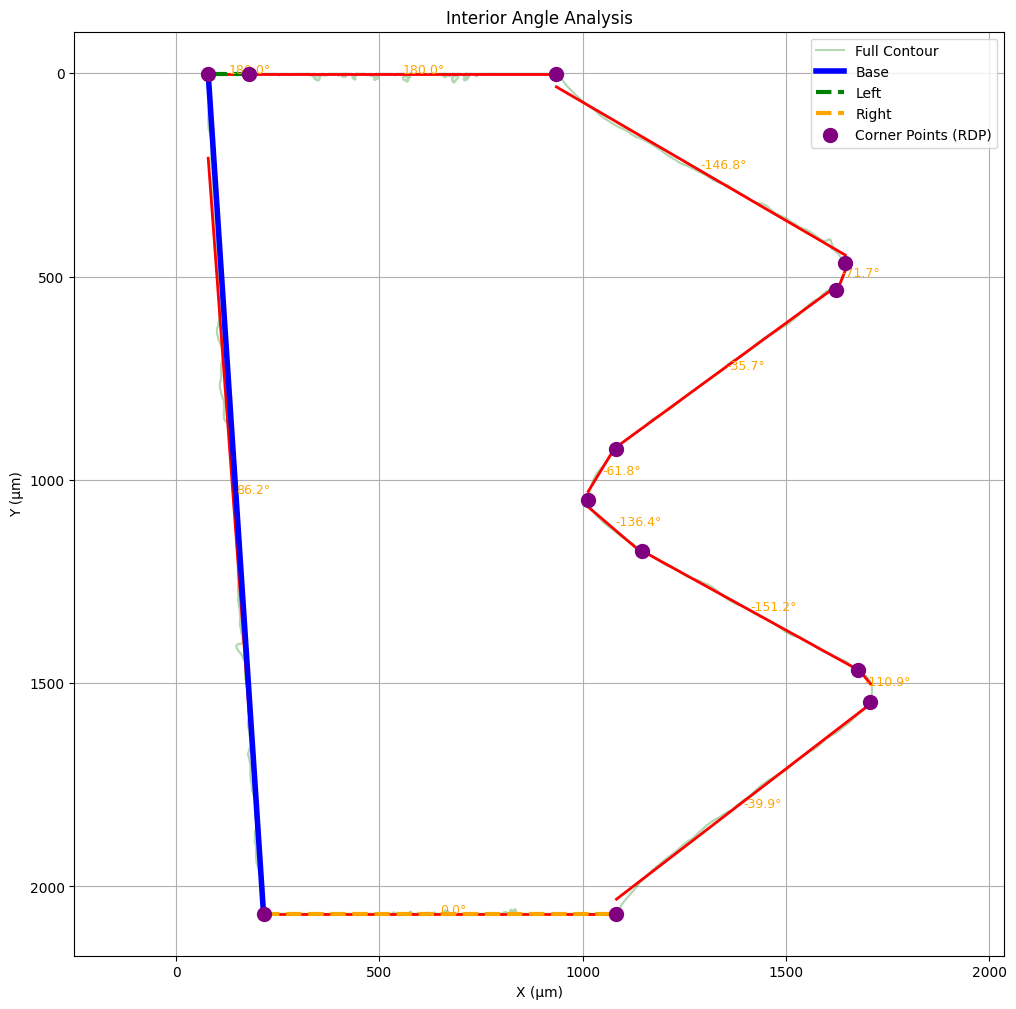

In [216]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import degrees
from skimage.measure import approximate_polygon
from sklearn.linear_model import LinearRegression
import os


def calculate_signed_area(contour):
    x = contour[:, 0, 0]
    y = contour[:, 0, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


def analyze_interior_angles(image_path, px_size=0.56, rdp_tolerance=40.0):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Error: Could not read the image at {image_path}")
        return

    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        print("Error: No contours found.")
        return

    main_contour = max(contours, key=cv2.contourArea)
    contour_area = calculate_signed_area(main_contour)
    is_ccw = contour_area > 0
    contour_points = main_contour.reshape(-1, 2).astype(np.float32)
    contour_points *= px_size  # convert to μm

    coords_for_rdp = contour_points[:, ::-1]
    approx_coords = approximate_polygon(coords_for_rdp, tolerance=rdp_tolerance)
    corner_points = approx_coords[:, ::-1]

    print(f"\n📂 File: {os.path.basename(image_path)}")
    print(
        f"📐 RDP Tolerance = {rdp_tolerance}, Found {len(corner_points)} corner points."
    )

    plt.figure(figsize=(12, 12))
    plt.plot(
        contour_points[:, 0],
        contour_points[:, 1],
        "g-",
        alpha=0.3,
        label="Full Contour",
    )

    # ---------- Segment 擬合 ----------
    segments = []
    angles = []
    for i in range(len(corner_points)):
        pt_start = corner_points[i]
        pt_end = corner_points[(i + 1) % len(corner_points)]

        x0, y0 = pt_start
        x1, y1 = pt_end

        min_x, max_x = sorted([x0, x1])
        min_y, max_y = sorted([y0, y1])
        in_segment_mask = (
            (contour_points[:, 0] >= min_x)
            & (contour_points[:, 0] <= max_x)
            & (contour_points[:, 1] >= min_y)
            & (contour_points[:, 1] <= max_y)
        )
        segment_pts = contour_points[in_segment_mask]
        if len(segment_pts) < 2:
            continue

        X = segment_pts[:, 0].reshape(-1, 1)
        Y = segment_pts[:, 1].reshape(-1, 1)
        model = LinearRegression().fit(X, Y)
        x_fit = np.array([x0, x1]).reshape(-1, 1)
        y_fit = model.predict(x_fit)

        plt.plot(x_fit, y_fit, "r-", linewidth=2)

        vec = np.array([x1 - x0, y1 - y0])
        angle_rad = np.arctan2(vec[1], vec[0])
        angle_deg = np.degrees(angle_rad)
        angles.append(angle_deg)
        segments.append((pt_start, pt_end))

        cx, cy = (pt_start + pt_end) / 2
        plt.text(cx, cy, f"{angle_deg:.1f}°", color="orange", fontsize=9)

    # ---------- 基板與斜邊判斷 ----------
    base_idx = np.argmin([abs(abs(a) - 90) for a in angles])
    base_angle = angles[base_idx]
    left_idx = (base_idx - 1 + len(angles)) % len(angles)
    right_idx = (base_idx + 1) % len(angles)

    # 向量定義
    def unit_vector(p1, p2):
        vec = p2 - p1
        return vec / np.linalg.norm(vec)

    def angle_between(v1, v2):
        cos_theta = np.clip(np.dot(v1, v2), -1.0, 1.0)
        return np.degrees(np.arccos(cos_theta))

    v_base = unit_vector(*segments[base_idx])
    v_left = unit_vector(*segments[left_idx])
    v_right = unit_vector(*segments[right_idx])

    angle_left = angle_between(-v_base, v_left)
    angle_right = angle_between(-v_base, v_right)

    print(f"\n🟦 基板 segment：index={base_idx}, angle={base_angle:.2f}°")
    print(f"🔻 左斜邊與基板夾角：{angle_left:.2f}°")
    print(f"🔺 右斜邊與基板夾角：{angle_right:.2f}°")

    # ---------- 視覺化強調 ----------
    pt1, pt2 = segments[base_idx]
    plt.plot([pt1[0], pt2[0]], [pt1[1], pt2[1]], "blue", linewidth=4, label="Base")

    for idx, label, color in zip(
        [left_idx, right_idx], ["Left", "Right"], ["green", "orange"]
    ):
        pt1, pt2 = segments[idx]
        plt.plot(
            [pt1[0], pt2[0]],
            [pt1[1], pt2[1]],
            color=color,
            linewidth=3,
            linestyle="--",
            label=label,
        )

    # ---------- 結束視覺化 ----------
    plt.scatter(
        corner_points[:, 0],
        corner_points[:, 1],
        c="purple",
        s=100,
        zorder=5,
        label="Corner Points (RDP)",
    )
    plt.xlabel("X (μm)")
    plt.ylabel("Y (μm)")
    plt.legend()
    plt.grid(True)
    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.title("Interior Angle Analysis")
    plt.show()

# --- Main execution block ---
try:
    # Use the user-provided image
    image_path = (
        r"\\140.114.141.95\nas\112\112033635_CHI\GA\0729OM\0.9_0.9_60_binary01_crop.png"
        # r"\\140.114.141.95\nas\112\112033635_CHI\GA\0729OM\0.76_0.9_59_binary02_crop_clean.png"
    )

    # Adjust rdp_tolerance to control the number of corners.
    analyze_interior_angles(image_path, rdp_tolerance=30.0)
except FileNotFoundError:
    print(f"Error: File not found. Please check the path.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

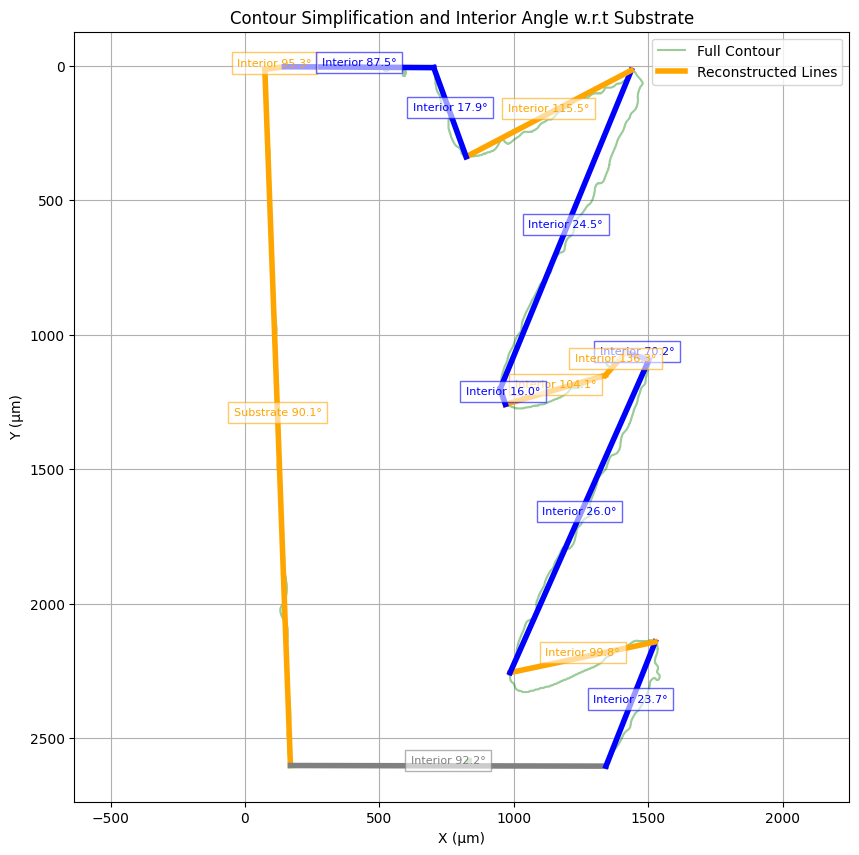

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import degrees
from skimage.measure import approximate_polygon
from os.path import basename


def calculate_signed_area(contour):
    if contour.ndim == 3:
        contour = contour.reshape(-1, 2)
    x, y = contour[:, 0], contour[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


def vector_angle(v1, v2):
    """計算兩向量夾角 (0~180°)"""
    dot = np.dot(v1, v2)
    norm = np.linalg.norm(v1) * np.linalg.norm(v2)
    if norm == 0:
        return np.nan
    angle = degrees(np.arccos(np.clip(dot / norm, -1.0, 1.0)))
    return angle


def analyze_contour_final(image_path, px_size=0.56, rdp_tolerance=15.0):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"❌ Error: Could not read image at {image_path}")
        return

    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        print("❌ Error: No contours found.")
        return

    main_contour = max(contours, key=cv2.contourArea)
    contour_points = main_contour.reshape(-1, 2).astype(np.float32)
    corner_points = approximate_polygon(contour_points, tolerance=rdp_tolerance)

    if not np.allclose(corner_points[0], corner_points[-1]):
        corner_points = np.vstack([corner_points, corner_points[0]])

    corner_points_scaled = corner_points * px_size

    # --- 合併線段 ---
    merged_segments = []
    i = 0
    while i < len(corner_points_scaled) - 1:
        p_start = corner_points_scaled[i]
        p_curr = p_start
        j = i + 1

        dx = corner_points_scaled[j][0] - p_curr[0]
        dz = corner_points_scaled[j][1] - p_curr[1]
        angle = degrees(np.arctan2(-dz, dx))
        direction = "Up" if angle > 10 else "Down" if angle < -10 else "Flat"

        angle_sum = angle
        seg_count = 1

        while j < len(corner_points_scaled) - 1:
            p_next = corner_points_scaled[j + 1]
            dx_next = p_next[0] - p_curr[0]
            dz_next = p_next[1] - p_curr[1]
            angle_next = degrees(np.arctan2(-dz_next, dx_next))

            direction_next = (
                "Up" if angle_next > 10 else "Down" if angle_next < -10 else "Flat"
            )

            if direction_next != direction or abs(angle_next - angle) > 10:
                break

            angle_sum += angle_next
            seg_count += 1
            p_curr = p_next
            j += 1

        p_end = corner_points_scaled[i + seg_count]
        avg_angle = angle_sum / seg_count
        merged_segments.append((p_start, p_end, direction, avg_angle))

        i += seg_count

    # --- 找基板線段 ---
    substrate_seg = None
    for seg in merged_segments:
        p1, p2, direction, ang = seg
        if direction == "Down" and abs(abs(ang) - 90) < 5:  # 接近垂直
            substrate_seg = seg
            break

    if substrate_seg is None:
        print("⚠ 找不到基板線段")
        return

    # 基板方向向量
    sub_vec = np.array(substrate_seg[1]) - np.array(substrate_seg[0])

    # --- 畫圖 ---
    plt.figure(figsize=(10, 10))
    plt.plot(
        contour_points[:, 0] * px_size,
        contour_points[:, 1] * px_size,
        "g-",
        alpha=0.4,
        label="Full Contour",
    )

    for p1, p2, direction, angle_deg in merged_segments:
        color = (
            "blue" if direction == "Up" else "orange" if direction == "Down" else "gray"
        )
        plt.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, linewidth=4)

        # 計算與基板內角
        vec =  np.array(p2) - np.array(p1)
        ang_between = vector_angle(vec, sub_vec)
        interior_angle = (
            180 - ang_between  # 180 - ang_between if ang_between > 90 else ang_between
        )

        if (p1 == substrate_seg[0]).all() and (p2 == substrate_seg[1]).all():
            label_text = f"Substrate {abs(angle_deg):.1f}°"
        else:
            label_text = f"Interior {interior_angle:.1f}°"

        mid_x, mid_y = (p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2
        plt.text(
            mid_x,
            mid_y,
            label_text,
            fontsize=8,
            color=color,
            ha="center",
            va="bottom",
            bbox=dict(facecolor="white", alpha=0.6, edgecolor=color),
        )

    plt.title("Contour Simplification and Interior Angle w.r.t Substrate")
    plt.xlabel("X (μm)")
    plt.ylabel("Y (μm)")
    plt.legend(["Full Contour", "Reconstructed Lines"])
    plt.grid(True)
    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.show()


# --- 執行 ---
image_path = r"C:\Users\cchih\Desktop\NTHU\MasterThesis\research_log\202508\0801\RemoveBackground\0.9_0.9_120.png"
analyze_contour_final(image_path, rdp_tolerance=60)